# CHAPTER 1: INTRODUCTION AND PROBLEM STATEMENT

## INTRODUCTION TO THE COMPANY
> This organization specializes in developing **intelligent content discovery systems** that enhance user engagement by providing highly relevant suggestions. Using **data-driven insights** and cutting-edge algorithms, the platform tailors its recommendations to match individual user preferences. It processes large-scale datasets containing user interactions and viewing patterns to create a seamless and intuitive movie exploration experience. By continually refining its models and incorporating feedback loops, the platform ensures that users receive accurate and timely suggestions, resulting in increased satisfaction and prolonged platform usage.

## DEFINITION OF THE PROBLEM 
> In an era where digital platforms offer an overwhelming amount of content, users often face **decision fatigue** when choosing movies. Without an efficient system to guide their choices, users may miss out on content aligned with their preferences. This project focuses on creating a **dynamic recommendation engine** capable of analyzing historical user behavior and identifying patterns to suggest relevant movies. By utilizing **collaborative filtering, matrix decomposition, and similarity-based techniques**, the goal is to enhance content discovery and streamline the user’s decision-making process.


## IMPORTING THE LIBRARIES AND DATASET

### Importing all the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
import regex as re
import pickle
import mlflow
import chardet
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from cmfrec import CMF
from sklearn.manifold import TSNE

### Importing the dataset

In [2]:
warnings.filterwarnings('ignore')

# Chardet library used detect the encoding style of the dat file
with open(r"C:\Users\saina\Desktop\DS_ML_AI\Scaler\Module_16_ML_Time_Series_Analysis_and_Recomm_sys\Case_Studies\Zee_Recommendation_System\dataset\zee-movies.dat","rb") as f:
    result = chardet.detect(f.read())

movies = pd.read_csv(r"C:\Users\saina\Desktop\DS_ML_AI\Scaler\Module_16_ML_Time_Series_Analysis_and_Recomm_sys\Case_Studies\Zee_Recommendation_System\dataset\zee-movies.dat",encoding=result["encoding"],sep = "::")
users = pd.read_csv(r"c:\Users\saina\Desktop\DS_ML_AI\Scaler\Module_16_ML_Time_Series_Analysis_and_Recomm_sys\Case_Studies\Zee_Recommendation_System\dataset\zee-users.dat",encoding=result["encoding"],sep = "::")
ratings = pd.read_csv(r"c:\Users\saina\Desktop\DS_ML_AI\Scaler\Module_16_ML_Time_Series_Analysis_and_Recomm_sys\Case_Studies\Zee_Recommendation_System\dataset\zee-ratings.dat",encoding=result["encoding"],sep = "::")

In [3]:
movies.head()

,Movie ID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [5]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


### Description regarding data

#### 1. Ratings File (`ratings.dat`)

All ratings are stored in the file **`ratings.dat`** and follow the format:
- **UserID:** Ranges between 1 and 6040.  
- **MovieID:** Ranges between 1 and 3952.  
- **Rating:** Ratings are on a 5-star scale (whole-star ratings only).  
- **Timestamp:** The Unix timestamp represented in number of seconds since the Unix epoch (January 1, 1970, 00:00:00 UTC). This format is commonly known as Unix Timestamp or POSIX Time.
- Each user has rated at least 20 movies.

---

#### 2. Users File (`users.dat`)

User information is available in the file **`users.dat`** with the format:


- **Gender:**  
  - `M` for Male  
  - `F` for Female  

- **Age:**
  - * Indicated Age range as follow  
  - `1:` Under 18  
  - `18:` 18-24  
  - `25:` 25-34  
  - `35:` 35-44  
  - `45:` 45-49  
  - `50:` 50-55  
  - `56:` 56+  

- **Occupation Codes:**  
  - `0:` other or not specified  
  - `1:` academic/educator  
  - `2:` artist  
  - `3:` clerical/admin  
  - `4:` college/grad student  
  - `5:` customer service  
  - `6:` doctor/health care  
  - `7:` executive/managerial  
  - `8:` farmer  
  - `9:` homemaker  
  - `10:` K-12 student  
  - `11:` lawyer  
  - `12:` programmer  
  - `13:` retired  
  - `14:` sales/marketing  
  - `15:` scientist  
  - `16:` self-employed  
  - `17:` technician/engineer  
  - `18:` tradesman/craftsman  
  - `19:` unemployed  
  - `20:` writer  

---

#### 3. Movies File (`movies.dat`)

Movie information is stored in the file **`movies.dat`** with the format:


- **Title:** Identical to titles provided by IMDb, including the year of release inside the brackets().  
- **Genres:** Pipe-separated (`|`) values chosen from the following list:  

- Action, Adventure, Animation, Children's, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western

## ANALYSING BASIC METRICS OF INDIVIDUAL DATASETS

### Shape of the data

In [6]:
# Store datasets in a dictionary
datasets = {'movies': movies, 'users': users, 'ratings': ratings}

# Loop through the dictionary
for name, dataset in datasets.items():
    print(f"Number of rows in the {name} dataset = {dataset.shape[0]}")
    print(f"Number of columns in the {name} dataset = {dataset.shape[1]}")
    print()

Number of rows in the movies dataset = 3883
Number of columns in the movies dataset = 3

Number of rows in the users dataset = 6040
Number of columns in the users dataset = 5

Number of rows in the ratings dataset = 1000209
Number of columns in the ratings dataset = 4



### Datatypes of all the attributes

In [7]:
for name, dataset in datasets.items():
    dataset.info()
    print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Movie ID  3883 non-null   int64 
 1   Title     3883 non-null   object
 2   Genres    3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 2   Age         6040 non-null   int64 
 3   Occupation  6040 non-null   int64 
 4   Zip-code    6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     10002

**Observation**
> Zip-code should be string/object datatype even though they are numbers as they represent location. 

### Missing value or Null Value Detection

In [8]:
for name, dataset in datasets.items():
    print(f"Number of missing values in the {name} dataset = {dataset.isnull().sum().sum()}")
    print()

Number of missing values in the movies dataset = 0

Number of missing values in the users dataset = 0

Number of missing values in the ratings dataset = 0



**Observations**
> No Null values in any of the dataset

### Descriptive Statistics regarding each column of datasets

In [9]:
for dataset in datasets.values():
    print(dataset.describe())
    print()

          Movie ID
count  3883.000000
mean   1986.049446
std    1146.778349
min       1.000000
25%     982.500000
50%    2010.000000
75%    2980.500000
max    3952.000000

            UserID          Age   Occupation
count  6040.000000  6040.000000  6040.000000
mean   3020.500000    30.639238     8.146854
std    1743.742145    12.895962     6.329511
min       1.000000     1.000000     0.000000
25%    1510.750000    25.000000     3.000000
50%    3020.500000    25.000000     7.000000
75%    4530.250000    35.000000    14.000000
max    6040.000000    56.000000    20.000000

             UserID       MovieID        Rating     Timestamp
count  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06
mean   3.024512e+03  1.865540e+03  3.581564e+00  9.722437e+08
std    1.728413e+03  1.096041e+03  1.117102e+00  1.215256e+07
min    1.000000e+00  1.000000e+00  1.000000e+00  9.567039e+08
25%    1.506000e+03  1.030000e+03  3.000000e+00  9.653026e+08
50%    3.070000e+03  1.835000e+03  4.000000e+00  9

**Observation**
> Except Rating column in Rating dataset, remaining descriptive statistics are not very useful

> Average rating of from total Rating dataset is 3.58. Median is 4.  

In [10]:
for dataset in [movies, users]:
    print(dataset.describe(include='object'))
    print()

                        Title Genres
count                    3883   3883
unique                   3883    301
top     Contender, The (2000)  Drama
freq                        1    843

       Gender Zip-code
count    6040     6040
unique      2     3439
top         M    48104
freq     4331       19



In [11]:
users["Gender"].value_counts()

Gender
M    4331
F    1709
Name: count, dtype: int64

**Observation**
> Genres is showing as 301. But we need to split the genres first to get proper unique count.

> Male users are more than Female.

> 3439 Unique zip-codes are available.  

## ELABORATING USERS DATASET AND MERGING THE DATA FILES

### Elaborating Age, Gender, Occupation

In [3]:
# Gender Mapping
gender_dict = {
    'M': 'Male',
    'F': 'Female'
}

# Age Group Mapping
age_dict = {
    1: 'Under 18',
    18: '18-24',
    25: '25-34',
    35: '35-44',
    45: '45-49',
    50: '50-55',
    56: '56+'
}

# Occupation Mapping
occupation_dict = {
    0: 'other or not specified',
    1: 'academic/educator',
    2: 'artist',
    3: 'clerical/admin',
    4: 'college/grad student',
    5: 'customer service',
    6: 'doctor/health care',
    7: 'executive/managerial',
    8: 'farmer',
    9: 'homemaker',
    10: 'K-12 student',
    11: 'lawyer',
    12: 'programmer',
    13: 'retired',
    14: 'sales/marketing',
    15: 'scientist',
    16: 'self-employed',
    17: 'technician/engineer',
    18: 'tradesman/craftsman',
    19: 'unemployed',
    20: 'writer'
}

# Apply the mapping to the users dataset
users["Gender"] = users["Gender"].map(gender_dict)
users["Age_Category"] = users["Age"].map(age_dict)
users["Occupation_Category"] = users["Occupation"].map(occupation_dict)

In [4]:
users.head()

,UserID,Gender,Age,Occupation,Zip-code,Age_Category,Occupation_Category
0,1,Female,1,10,48067,Under 18,K-12 student
1,2,Male,56,16,70072,56+,self-employed
2,3,Male,25,15,55117,25-34,scientist
3,4,Male,45,7,02460,45-49,executive/managerial
4,5,Male,25,20,55455,25-34,writer


### Elaborating Zip Codes

In [5]:
# Dictionary of ZIP Code Ranges for US States
zip_code_ranges = {
    (35000, 36999): ("Alabama", "AL"),
    (99500, 99999): ("Alaska", "AK"),
    (85000, 86999): ("Arizona", "AZ"),
    (71600, 72999): ("Arkansas", "AR"),
    (90000, 96199): ("California", "CA"),
    (80000, 81999): ("Colorado", "CO"),
    (6000, 6999): ("Connecticut", "CT"),
    (19700, 19999): ("Delaware", "DE"),
    (32000, 34999): ("Florida", "FL"),
    (30000, 31999): ("Georgia", "GA"),
    (96700, 96999): ("Hawaii", "HI"),
    (83200, 83999): ("Idaho", "ID"),
    (60000, 62999): ("Illinois", "IL"),
    (46000, 47999): ("Indiana", "IN"),
    (50000, 52999): ("Iowa", "IA"),
    (66000, 67999): ("Kansas", "KS"),
    (40000, 42999): ("Kentucky", "KY"),
    (70000, 71599): ("Louisiana", "LA"),
    (3900, 4999): ("Maine", "ME"),
    (20600, 21999): ("Maryland", "MD"),
    (1000, 2799): ("Massachusetts", "MA"),
    (48000, 49999): ("Michigan", "MI"),
    (55000, 56999): ("Minnesota", "MN"),
    (38600, 39999): ("Mississippi", "MS"),
    (63000, 65999): ("Missouri", "MO"),
    (59000, 59999): ("Montana", "MT"),
    (27000, 28999): ("North Carolina", "NC"),
    (58000, 58999): ("North Dakota", "ND"),
    (68000, 69999): ("Nebraska", "NE"),
    (88900, 89999): ("Nevada", "NV"),
    (3000, 3899): ("New Hampshire", "NH"),
    (7000, 8999): ("New Jersey", "NJ"),
    (87000, 88499): ("New Mexico", "NM"),
    (10000, 14999): ("New York", "NY"),
    (43000, 45999): ("Ohio", "OH"),
    (73000, 74999): ("Oklahoma", "OK"),
    (97000, 97999): ("Oregon", "OR"),
    (15000, 19699): ("Pennsylvania", "PA"),
    (300, 999): ("Puerto Rico", "PR"),
    (2800, 2999): ("Rhode Island", "RI"),
    (29000, 29999): ("South Carolina", "SC"),
    (57000, 57999): ("South Dakota", "SD"),
    (37000, 38599): ("Tennessee", "TN"),
    (75000, 79999): ("Texas", "TX"),
    (88500, 88599): ("Texas", "TX"),
    (84000, 84999): ("Utah", "UT"),
    (5000, 5999): ("Vermont", "VT"),
    (22000, 24699): ("Virginia", "VA"),
    (20000, 20599): ("Washington DC", "DC"),
    (98000, 99499): ("Washington", "WA"),
    (24700, 26999): ("West Virginia", "WV"),
    (53000, 54999): ("Wisconsin", "WI"),
    (82000, 83199): ("Wyoming", "WY"),
}


In [6]:
# Function to map ZIP codes to states
def get_state_from_zip(zip_code):
    try:
        # Extract only the first 5 digits from ZIP code
        zip_code_int = int(str(zip_code)[:5])
        
        # Search for state in the ZIP code range
        for zip_range, (state, abbr) in zip_code_ranges.items():
            if zip_range[0] <= zip_code_int <= zip_range[1]:
                return state, abbr
        return "Unknown", "Unknown"
    except ValueError:
        return "Invalid", "Invalid"

In [7]:
# Apply function to DataFrame and create two new columns
users[["State", "State abbr"]] = users["Zip-code"].apply(
    lambda x: pd.Series(get_state_from_zip(x))
)

In [8]:
users.head()

,UserID,Gender,Age,Occupation,Zip-code,Age_Category,Occupation_Category,State,State abbr
0,1,Female,1,10,48067,Under 18,K-12 student,Michigan,MI
1,2,Male,56,16,70072,56+,self-employed,Louisiana,LA
2,3,Male,25,15,55117,25-34,scientist,Minnesota,MN
3,4,Male,45,7,02460,45-49,executive/managerial,Massachusetts,MA
4,5,Male,25,20,55455,25-34,writer,Minnesota,MN


In [9]:
users.isna().sum().sum()

np.int64(0)

### Merging the datasets

In [10]:
# Merge ratings with users on UserID using left join
merged_df = pd.merge(ratings, users, on='UserID', how='left')

In [11]:
merged_df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Age_Category,Occupation_Category,State,State abbr
0,1,1193,5,978300760,Female,1,10,48067,Under 18,K-12 student,Michigan,MI
1,1,661,3,978302109,Female,1,10,48067,Under 18,K-12 student,Michigan,MI
2,1,914,3,978301968,Female,1,10,48067,Under 18,K-12 student,Michigan,MI
3,1,3408,4,978300275,Female,1,10,48067,Under 18,K-12 student,Michigan,MI
4,1,2355,5,978824291,Female,1,10,48067,Under 18,K-12 student,Michigan,MI


In [12]:
merged_df.isna().sum().sum()

np.int64(0)

In [13]:
# Merge with movies where column names are different
final_df = pd.merge(merged_df, movies, how='left', left_on='MovieID', right_on='Movie ID')

In [14]:
# Drop the redundant column after merging
final_df.drop(columns=['Movie ID'], inplace=True)

In [15]:
final_df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Age_Category,Occupation_Category,State,State abbr,Title,Genres
0,1,1193,5,978300760,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,"Bug's Life, A (1998)",Animation|Children's|Comedy


# CHAPTER 2: EDA, DATA CLEANING, FEATURE ENGINEERING, TRAIN TEST SPLIT AND INTERACTION MATRIX

## DATA CLEANING

### Extracting Year and Title from Title column

In [16]:
print(final_df["Title"].head())

0    One Flew Over the Cuckoo's Nest (1975)
1          James and the Giant Peach (1996)
2                       My Fair Lady (1964)
3                    Erin Brockovich (2000)
4                      Bug's Life, A (1998)
Name: Title, dtype: object


**Observation**
> Year can be extracted from Title column by using string indexing from -5 to -1

In [17]:
# extracting year from title
final_df["Year"] = final_df["Title"].apply(lambda x: x[-5:-1])

In [18]:
# removing the year from title
final_df["Title"] = final_df["Title"].apply(lambda x: x[:-7])

In [19]:
final_df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Age_Category,Occupation_Category,State,State abbr,Title,Genres,Year
0,1,1193,5,978300760,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,One Flew Over the Cuckoo's Nest,Drama,1975
1,1,661,3,978302109,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,James and the Giant Peach,Animation|Children's|Musical,1996
2,1,914,3,978301968,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,My Fair Lady,Musical|Romance,1964
3,1,3408,4,978300275,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,Erin Brockovich,Drama,2000
4,1,2355,5,978824291,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,"Bug's Life, A",Animation|Children's|Comedy,1998


In [20]:
final_df.duplicated().sum()

np.int64(0)

### Splitting the Genre Column into list

In [21]:
final_df["Genres"] = final_df["Genres"].apply(lambda x: x.split("|"))

In [22]:
final_df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Age_Category,Occupation_Category,State,State abbr,Title,Genres,Year
0,1,1193,5,978300760,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,One Flew Over the Cuckoo's Nest,[Drama],1975
1,1,661,3,978302109,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,James and the Giant Peach,"[Animation, Children's, Musical]",1996
2,1,914,3,978301968,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,My Fair Lady,"[Musical, Romance]",1964
3,1,3408,4,978300275,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,Erin Brockovich,[Drama],2000
4,1,2355,5,978824291,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,"Bug's Life, A","[Animation, Children's, Comedy]",1998


### Explode the final_df dataset by Different Genres

In [23]:
exploded_df = final_df.explode('Genres')

In [24]:
exploded_df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Age_Category,Occupation_Category,State,State abbr,Title,Genres,Year
0,1,1193,5,978300760,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,One Flew Over the Cuckoo's Nest,Drama,1975
1,1,661,3,978302109,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,James and the Giant Peach,Animation,1996
1,1,661,3,978302109,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,James and the Giant Peach,Children's,1996
1,1,661,3,978302109,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,James and the Giant Peach,Musical,1996
2,1,914,3,978301968,Female,1,10,48067,Under 18,K-12 student,Michigan,MI,My Fair Lady,Musical,1964


In [25]:
exploded_df.isna().sum().sum()

np.int64(0)

In [26]:
exploded_df.duplicated().sum()

np.int64(0)

## FEATURE ENGINEERING

In [27]:
# convert the Timestamp to datetime
final_df["Timestamp"] = pd.to_datetime(final_df["Timestamp"], unit='s')


In [28]:
# Extract Date and Time features from Timestamp
final_df["RatingYear"] = final_df["Timestamp"].dt.year
final_df["RatingMonth"] = final_df["Timestamp"].dt.month
final_df["RatingDay"] = final_df["Timestamp"].dt.day
final_df["RatingHour"] = final_df["Timestamp"].dt.hour
final_df["RatingMinute"] = final_df["Timestamp"].dt.minute
final_df["RatingSecond"] = final_df["Timestamp"].dt.second
final_df["RatingWeekday"] = final_df["Timestamp"].dt.weekday

In [29]:
final_df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Age_Category,Occupation_Category,...,Title,Genres,Year,RatingYear,RatingMonth,RatingDay,RatingHour,RatingMinute,RatingSecond,RatingWeekday
0,1,1193,5,2000-12-31 22:12:40,Female,1,10,48067,Under 18,K-12 student,...,One Flew Over the Cuckoo's Nest,[Drama],1975,2000,12,31,22,12,40,6
1,1,661,3,2000-12-31 22:35:09,Female,1,10,48067,Under 18,K-12 student,...,James and the Giant Peach,"[Animation, Children's, Musical]",1996,2000,12,31,22,35,9,6
2,1,914,3,2000-12-31 22:32:48,Female,1,10,48067,Under 18,K-12 student,...,My Fair Lady,"[Musical, Romance]",1964,2000,12,31,22,32,48,6
3,1,3408,4,2000-12-31 22:04:35,Female,1,10,48067,Under 18,K-12 student,...,Erin Brockovich,[Drama],2000,2000,12,31,22,4,35,6
4,1,2355,5,2001-01-06 23:38:11,Female,1,10,48067,Under 18,K-12 student,...,"Bug's Life, A","[Animation, Children's, Comedy]",1998,2001,1,6,23,38,11,5


## EXPLORATORY DATA ANALYSIS

### User Analysis

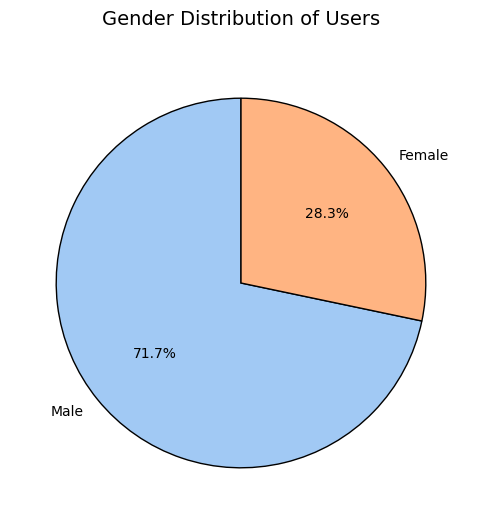

In [39]:
# Count of each gender
gender_counts = users['Gender'].value_counts()

# Plot Pie Chart using Matplotlib
plt.figure(figsize=(6, 6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})

# Add title and formatting
plt.title('Gender Distribution of Users', fontsize=14, pad=20)
plt.show()

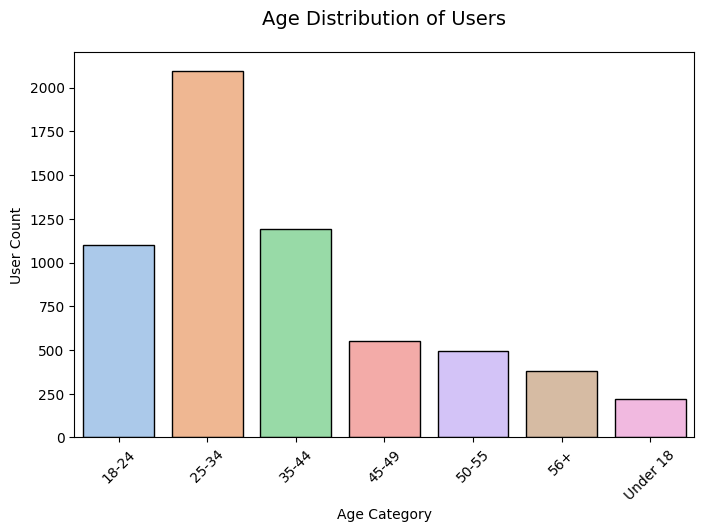

In [40]:
# Count of users in each age category
age_counts = users['Age_Category'].value_counts().sort_index()

# Plot bar chart using Seaborn
plt.figure(figsize=(8, 5))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='pastel', edgecolor='black')

# Add labels and title
plt.title('Age Distribution of Users', fontsize=14, pad=20)
plt.xlabel('Age Category')
plt.ylabel('User Count')
plt.xticks(rotation=45)
plt.show()

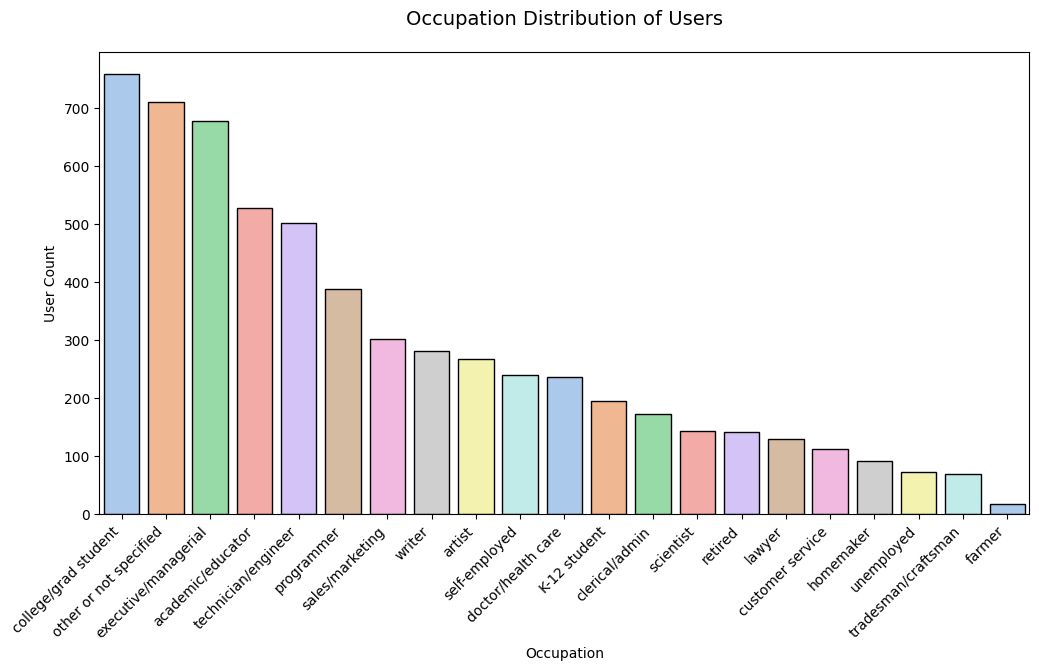

In [41]:
# Count of users in each occupation category
occupation_counts = users['Occupation_Category'].value_counts().sort_values(ascending=False)

# Plot bar chart using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x=occupation_counts.index, y=occupation_counts.values, palette='pastel', edgecolor='black')

# Add labels and title
plt.title('Occupation Distribution of Users', fontsize=14, pad=20)
plt.xlabel('Occupation')
plt.ylabel('User Count')
plt.xticks(rotation=45, ha='right')
plt.show()

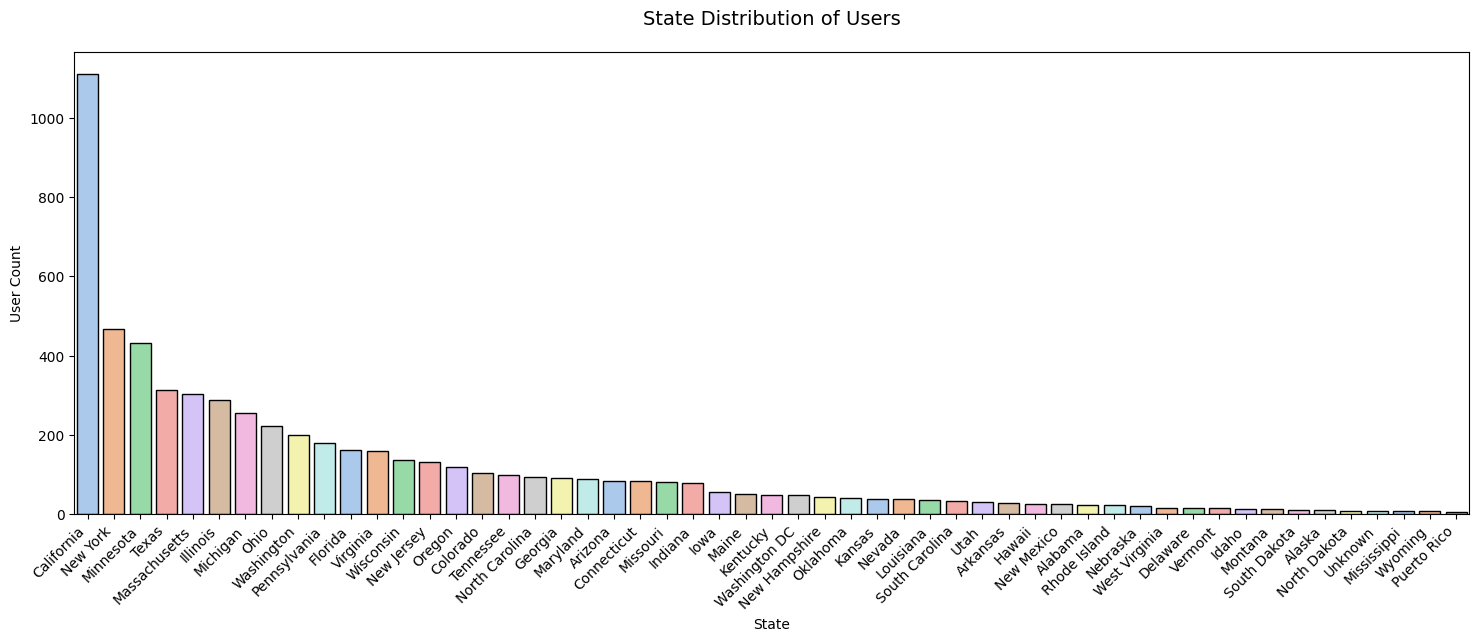

In [42]:
# Count of users in each State category
State_counts = users['State'].value_counts().sort_values(ascending=False)

# Plot bar chart using Seaborn
plt.figure(figsize=(18, 6))
sns.barplot(x=State_counts.index, y=State_counts.values, palette='pastel', edgecolor='black')

# Add labels and title
plt.title('State Distribution of Users', fontsize=14, pad=20)
plt.xlabel('State')
plt.ylabel('User Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [43]:
# Group data to get user count per state
state_user_count = users['State abbr'].value_counts().reset_index()
state_user_count.columns = ['State abbr', 'count']

# Plotly Choropleth Map
fig = go.Figure(data=go.Choropleth(
    locations=state_user_count['State abbr'],  # State abbreviations (e.g., CA, TX, NY)
    z=state_user_count['count'],  # User counts
    locationmode='USA-states',  # Map to US states
    colorscale='Viridis',  # Color scheme
    colorbar_title='Users',  # Color bar title
    marker_line_color='white',  # State boundaries
    marker_line_width=0.5
))

# Layout and Title
fig.update_layout(
    title_text='State-wise Distribution of Users',
    geo_scope='usa',  # Focus on USA
    title_x=0.5,  # Center title
    title_y=0.9,
    coloraxis_colorbar=dict(
        title="Number of Users",
        thicknessmode="pixels",
        thickness=10,
        lenmode="pixels",
        len=300
    )
)

# Show the plot
fig.show()


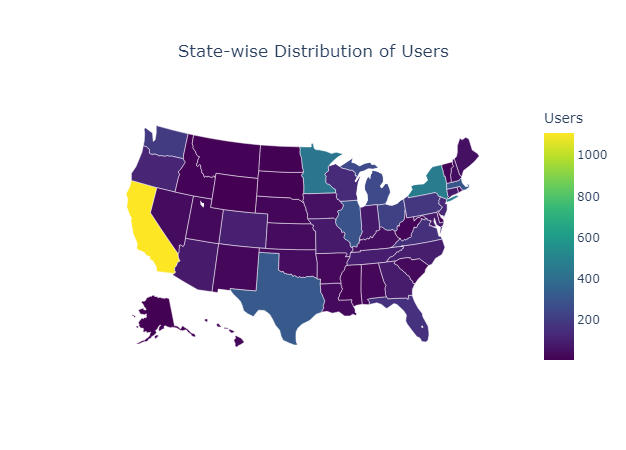


**Observations**
> Gender distribution among users, with **males forming 71.7%** of the group and **females accounting for 28.3%**, highlighting a significant skew toward male representation.

> The dominance of the **25-34 age group**, which has the highest user count, surpassing 2000. In contrast, **under 18s** represent the smallest fraction, with fewer than 250 users, showcasing distinct variations across age categories.

> The **college/grad student category** leads significantly in user count, showcasing over 750 users. In comparison, professions like **farming** see the least representation, highlighting a skew toward student demographics.

> The **state-wise user distribution**, with **California leading prominently** at over 1000 users. Meanwhile, **Wyoming, Mississippi, and Puerto Rico** have the least representation, highlighting regional diversity among the users.


### Movie Analysis

In [30]:
# extracted year and exploded genres
exploded_movies = movies.copy()
exploded_movies["Year"] = exploded_movies["Title"].apply(lambda x: int(x[-5:-1]))
exploded_movies["Title"] = exploded_movies["Title"].apply(lambda x: x[:-7])
exploded_movies["Genres"] = exploded_movies["Genres"].apply(lambda x: x.split("|"))
exploded_movies = exploded_movies.explode("Genres")
exploded_movies.head()

,Movie ID,Title,Genres,Year
0,1,Toy Story,Animation,1995
0,1,Toy Story,Children's,1995
0,1,Toy Story,Comedy,1995
1,2,Jumanji,Adventure,1995
1,2,Jumanji,Children's,1995


In [30]:
exploded_movies["Year"].max()

np.int64(2000)

In [31]:
exploded_movies["Year"].min()

np.int64(1919)

In [31]:
# Define decade bins and labels
bins = list(range(1910, 2010, 10))  # Decades from 1910 to 2000
labels = [f"{decade}s" for decade in range(1910, 2000, 10)]  # Corrected labels

# Create a 'Decade' column by binning the 'Year'
exploded_movies['Decade'] = pd.cut(exploded_movies['Year'], bins=bins, labels=labels, right=False)

exploded_movies.head()

,Movie ID,Title,Genres,Year,Decade
0,1,Toy Story,Animation,1995,1990s
0,1,Toy Story,Children's,1995,1990s
0,1,Toy Story,Comedy,1995,1990s
1,2,Jumanji,Adventure,1995,1990s
1,2,Jumanji,Children's,1995,1990s


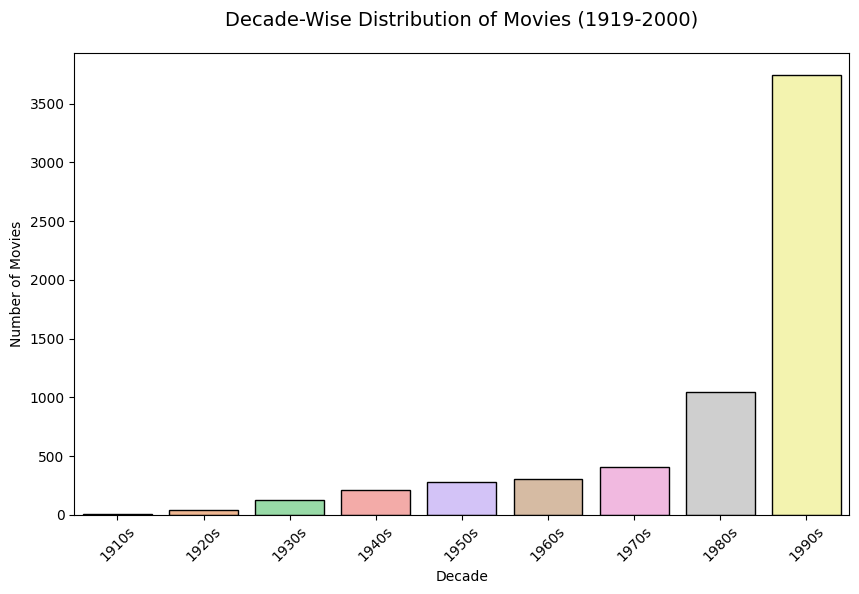

In [32]:
# Count the number of movies per decade
decade_counts = exploded_movies['Decade'].value_counts().sort_index()

# Plot bar chart using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='pastel', edgecolor='black')

# Add labels and title
plt.title('Decade-Wise Distribution of Movies (1919-2000)', fontsize=14, pad=20)
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

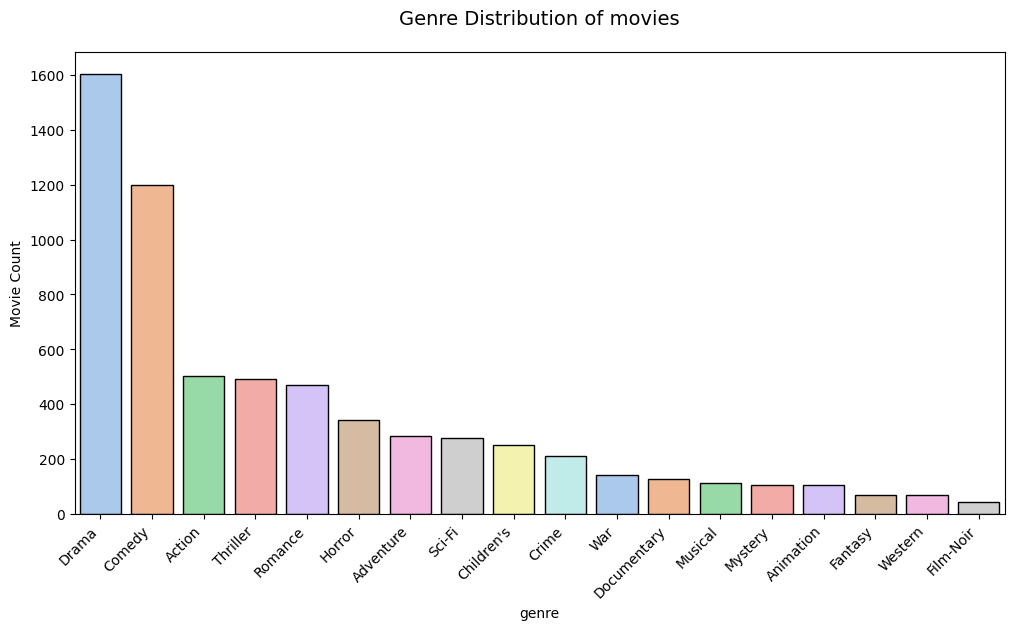

In [33]:
# Count of movies in each genre category
genre_counts = exploded_movies['Genres'].value_counts().sort_values(ascending=False)

# Plot bar chart using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='pastel', edgecolor='black')

# Add labels and title
plt.title('Genre Distribution of movies', fontsize=14, pad=20)
plt.xlabel('genre')
plt.ylabel('Movie Count')
plt.xticks(rotation=45, ha='right')
plt.show()

**Observations**
> The **decade-wise distribution of movies (1919-2000)** highlights an exponential rise in production, with the **1990s leading significantly** at over 3500 movies. Earlier decades, like the **1910s and 1920s**, trail far behind, showing the industry's massive growth over time.

> The **genre distribution of movies** reveals that **Drama dominates** with around 1600 movies, followed by **Comedy** at approximately 1200. Other genres, like **Film-Noir**, represent the smallest fraction, highlighting notable disparities in popularity.

### Ratings or final_df Analysis

#### Distributions

In [50]:
final_df["RatingYear"].max()

np.int32(2003)

In [51]:
final_df["RatingYear"].min()

np.int32(2000)

In [52]:
print(f'Mean rating score is {final_df.Rating.mean()}')
print(f'Median rating score is {final_df.Rating.median()}')

Mean rating score is 3.581564453029317
Median rating score is 4.0


<Axes: xlabel='Rating'>

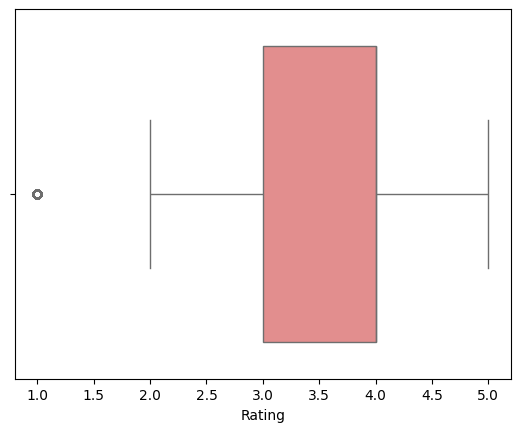

In [ ]:
sns.boxplot(x='Rating', data=final_df, color='lightcoral')

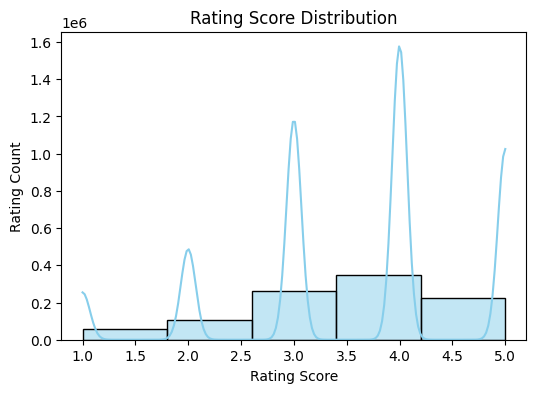

In [53]:
# Plot histogram for Rating distribution
plt.figure(figsize=(6, 4))
sns.histplot(final_df['Rating'], bins=5, kde=True, color='skyblue')
plt.title('Rating Score Distribution')
plt.xlabel('Rating Score')
plt.ylabel('Rating Count')
plt.show()

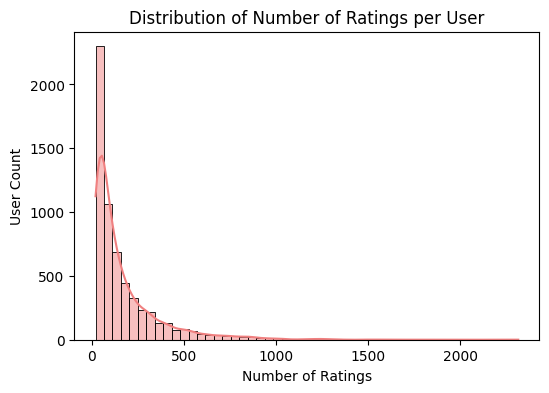

In [54]:
plt.figure(figsize=(6, 4))
sns.histplot(final_df['UserID'].value_counts(), bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('User Count')
plt.show()


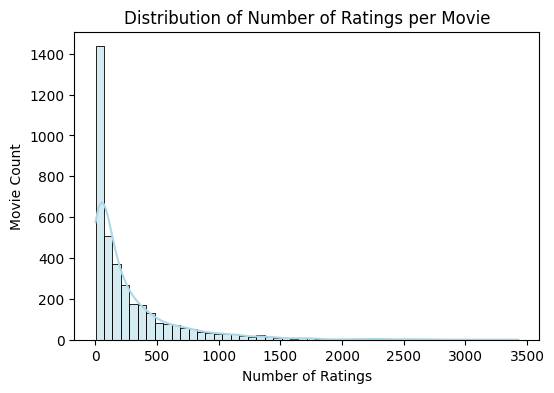

In [55]:
plt.figure(figsize=(6, 4))
sns.histplot(final_df['MovieID'].value_counts(), bins=50, kde=True, color='lightblue')
plt.title('Distribution of Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Count')
plt.show()


**Observations**
> The **box plot for ratings** indicates that the interquartile range (IQR) spans from **3.0 to 4.0**, with a **median of 3.5**. Whiskers stretch from **2.0 to 5.0**, and there’s an **outlier at 1.0**, highlighting the main distribution of ratings with a few exceptions.

> The **rating score distribution** reveals notable peaks at scores around **2.0, 3.0, 4.0, and 5.0**, indicating popular preference levels. The histogram and density plot highlight how rating scores are spread, with counts reaching up to **1.6 million**.

> The **distribution of number of ratings per user** reveals that the majority of users provide **fewer than 100 ratings**, with user counts sharply decreasing as the number of ratings increases. This trend highlights the varying levels of engagement among users.

> The **distribution of number of ratings per movie** showcases a sharp peak at lower ratings counts, with a large majority receiving fewer than 500 ratings. Movies with higher rating counts beyond **3000 are exceptionally rare**, highlighting disparities in movie popularity.

#### Bar and Count plots

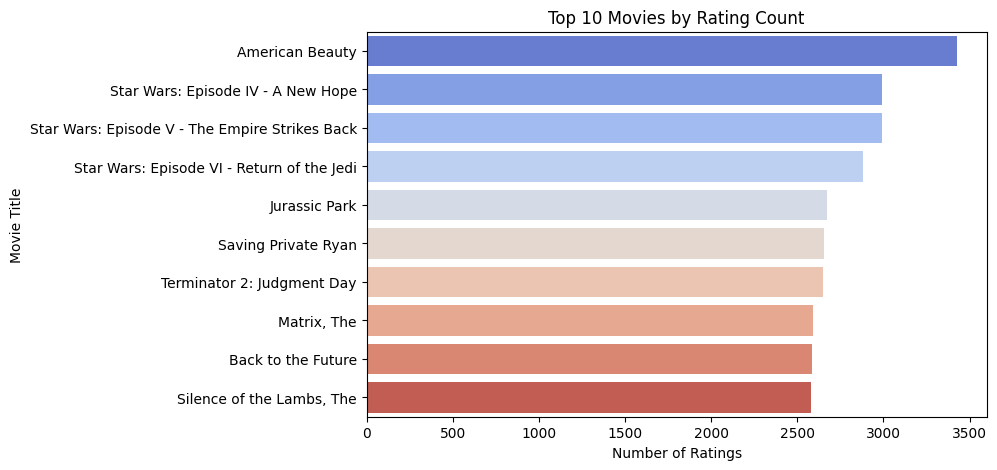

In [56]:
top_movies = final_df['Title'].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y=top_movies.index, x=top_movies.values, palette='coolwarm')
plt.title('Top 10 Movies by Rating Count')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()


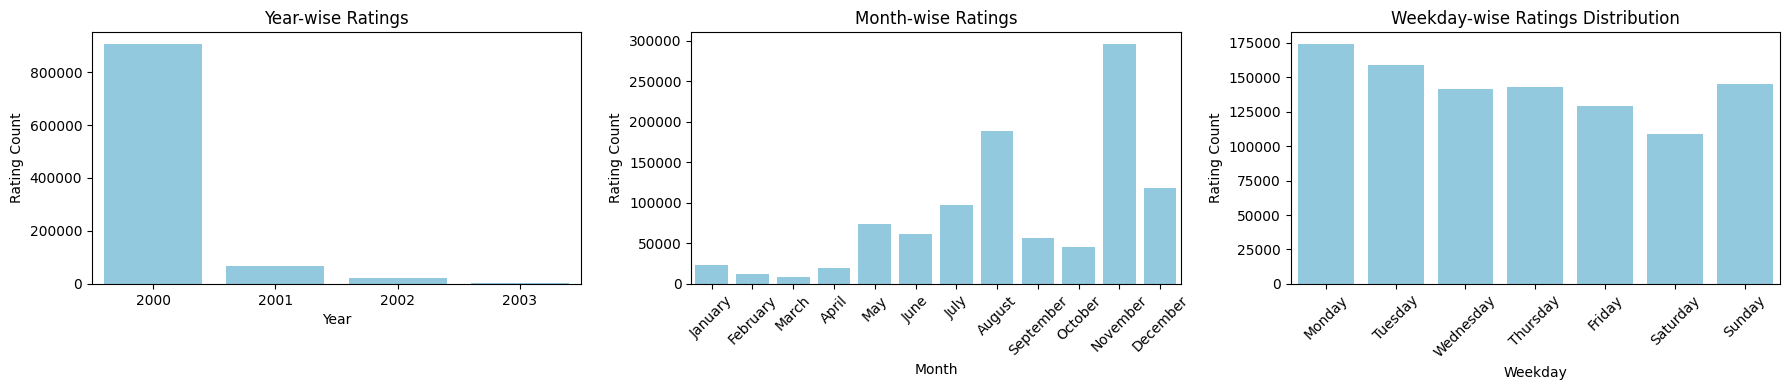

In [34]:
# Year-wise Ratings Distribution
plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1)
sns.countplot(x='RatingYear', data=final_df, color='skyblue')
plt.title('Year-wise Ratings')
plt.xlabel('Year')
plt.ylabel('Rating Count')

# Month-wise Ratings Distribution
month_map = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

# Map the weekday numbers to actual weekday names
final_df['RatingMonth_name'] = final_df['RatingMonth'].map(month_map)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.subplot(1, 3, 2)
sns.countplot(x=pd.Categorical(final_df['RatingMonth_name'], categories=month_order, ordered=True), 
              color='skyblue')
plt.title('Month-wise Ratings')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Rating Count')

# Weekday-wise Ratings Distribution
# Map numeric weekdays to weekday names
weekday_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

# Map the weekday numbers to actual weekday names
final_df['RatingWeekday_name'] = final_df['RatingWeekday'].map(weekday_map)

# Corrected Plot
plt.subplot(1, 3, 3)
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x=pd.Categorical(final_df['RatingWeekday_name'], categories=week_order, ordered=True), 
              color='skyblue')
plt.title('Weekday-wise Ratings Distribution')
plt.xticks(rotation=45)
plt.xlabel('Weekday')
plt.ylabel('Rating Count')
plt.tight_layout()
plt.show()


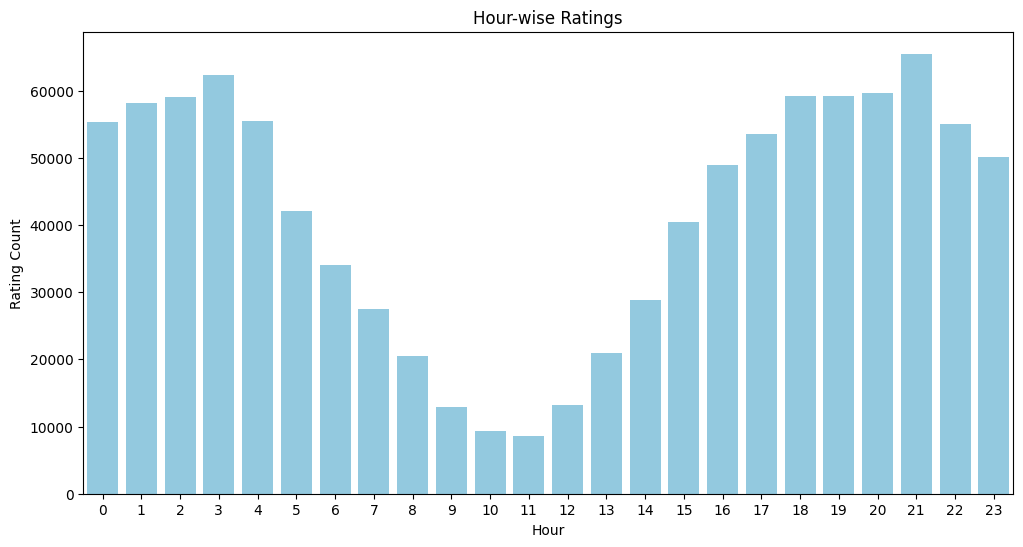

In [65]:
plt.figure(figsize=(12,6))
sns.countplot(x='RatingHour', data=final_df, color='skyblue')
plt.title('Hour-wise Ratings')
plt.xlabel('Hour')
plt.ylabel('Rating Count')
plt.show()

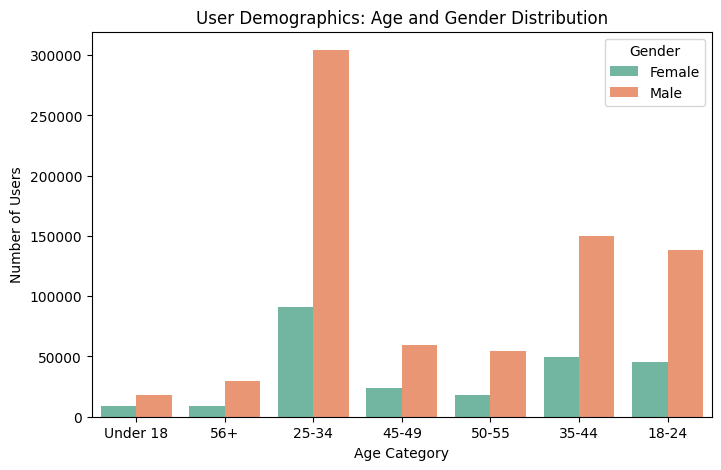

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Age_Category', hue='Gender', data=final_df, palette='Set2')
plt.title('User Demographics: Age and Gender Distribution')
plt.xlabel('Age Category')
plt.ylabel('Number of Users')
plt.legend(title='Gender')
plt.show()


**Observations**
> The **Top 10 Movies by Rating Count** showcases **American Beauty** leading with the highest number of ratings. Meanwhile, **The Silence of the Lambs** rounds out the list, demonstrating significant popularity contrasts within the top-rated movies.

> 1. **Year-wise Ratings (2000-2003)**: The year **2000 dominates**, exceeding **800,000 ratings**, while **2003 has the least activity**.  
> 2. **Month-wise Ratings**: **November leads** with more than **300,000 ratings**, contrasting with **January's low count**.  
> 3. **Weekday-wise Ratings Distribution**: **Monday stands out** with over **175,000 ratings**, while **Saturday lag behind**.
> 4. The **hour-wise ratings chart** reveals peaks at **hours 3 and 21**, where the rating count exceeds **60,000**. Meanwhile, **hours 10 and 11** show the least activity, with counts dropping below **10,000**, providing insights into user behavior across the day.

> The **age and gender distribution of users** indicates that the **25-34 male category dominates** with approximately 300,000 users. The **Under 18 and 56+ categories** show the lowest representation across both genders, highlighting the primary target audience.

#### Heat maps

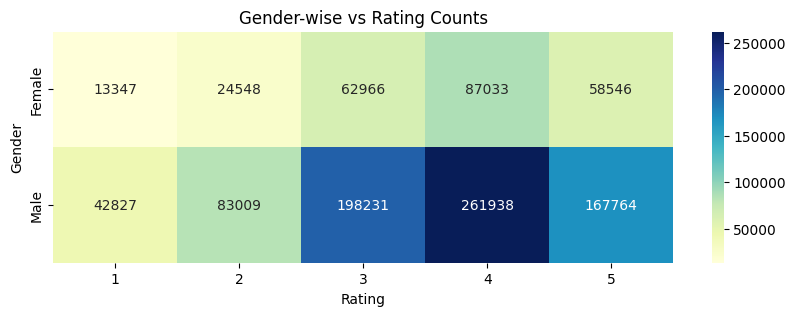

In [76]:
# Gender vs Rating Count Distribution
Gender_rating = final_df.groupby(['Rating', 'Gender']).size().reset_index(name='count')

# Correct pivot syntax using keyword arguments
pivot_table_Gender = Gender_rating.pivot_table(index='Gender', columns='Rating', values='count', fill_value=0)

# Plot heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(pivot_table_Gender, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Gender-wise vs Rating Counts')
plt.xlabel('Rating')
plt.ylabel('Gender')
plt.show()


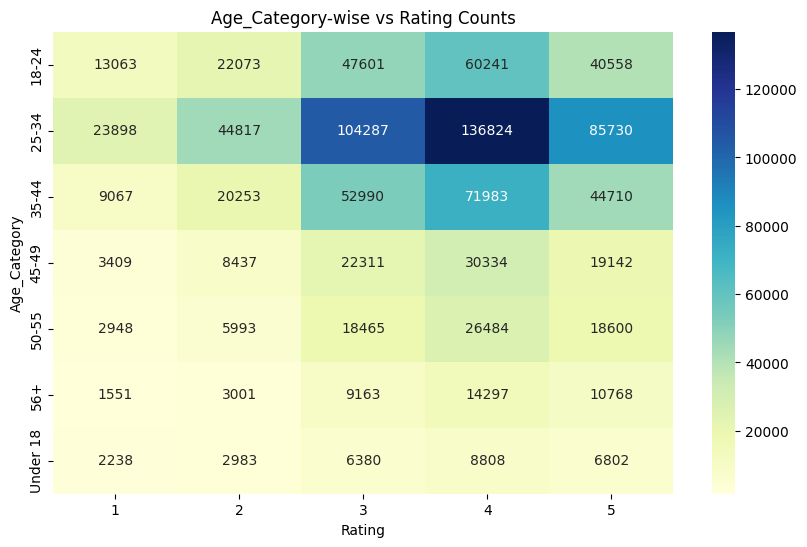

In [69]:
# Age_Category vs Rating Count Distribution
Age_Category_rating = final_df.groupby(['Rating', 'Age_Category']).size().reset_index(name='count')

# Correct pivot syntax using keyword arguments
pivot_table_Age_Category = Age_Category_rating.pivot_table(index='Age_Category', columns='Rating', values='count', fill_value=0)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table_Age_Category, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Age_Category-wise vs Rating Counts')
plt.xlabel('Rating')
plt.ylabel('Age_Category')
plt.show()


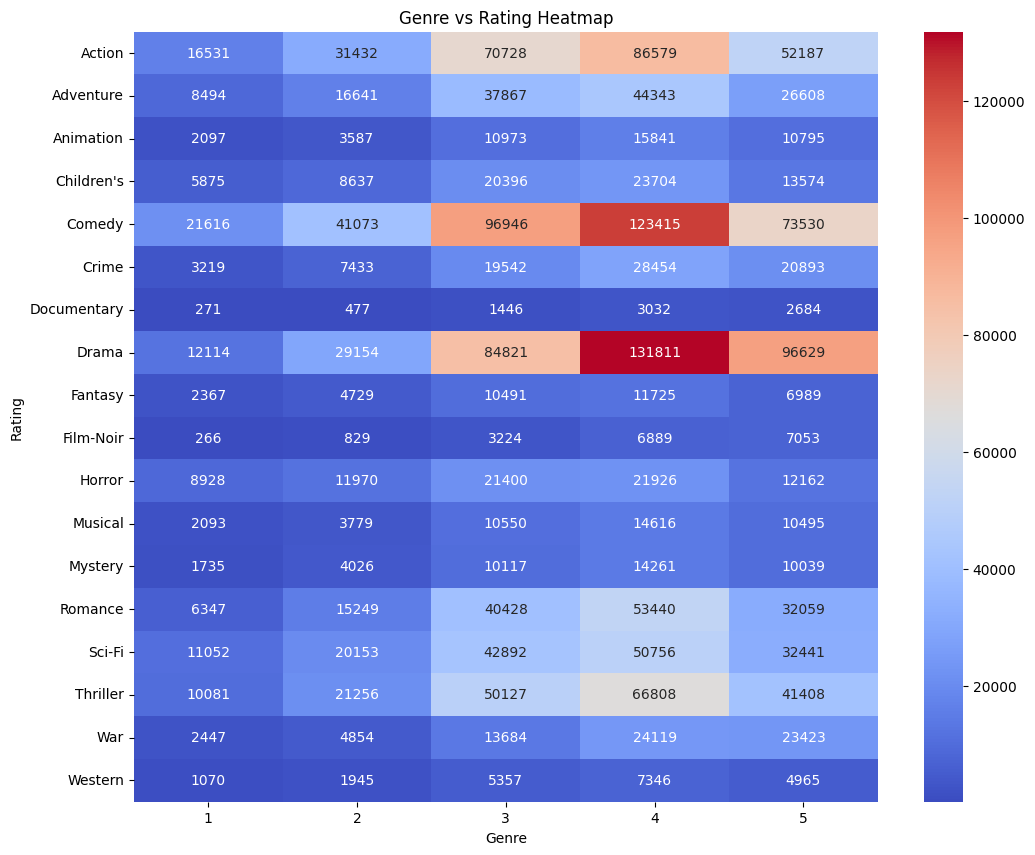

In [77]:
# Genre-wise Ratings
genre_rating = final_df.explode('Genres').groupby(['Rating', 'Genres']).size().reset_index(name='count')
pivot_table_genre = genre_rating.pivot_table(columns= 'Rating',index = 'Genres',values= 'count',fill_value = 0)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table_genre, annot=True, fmt='.0f', cmap='coolwarm')
plt.title('Genre vs Rating Heatmap')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.show()

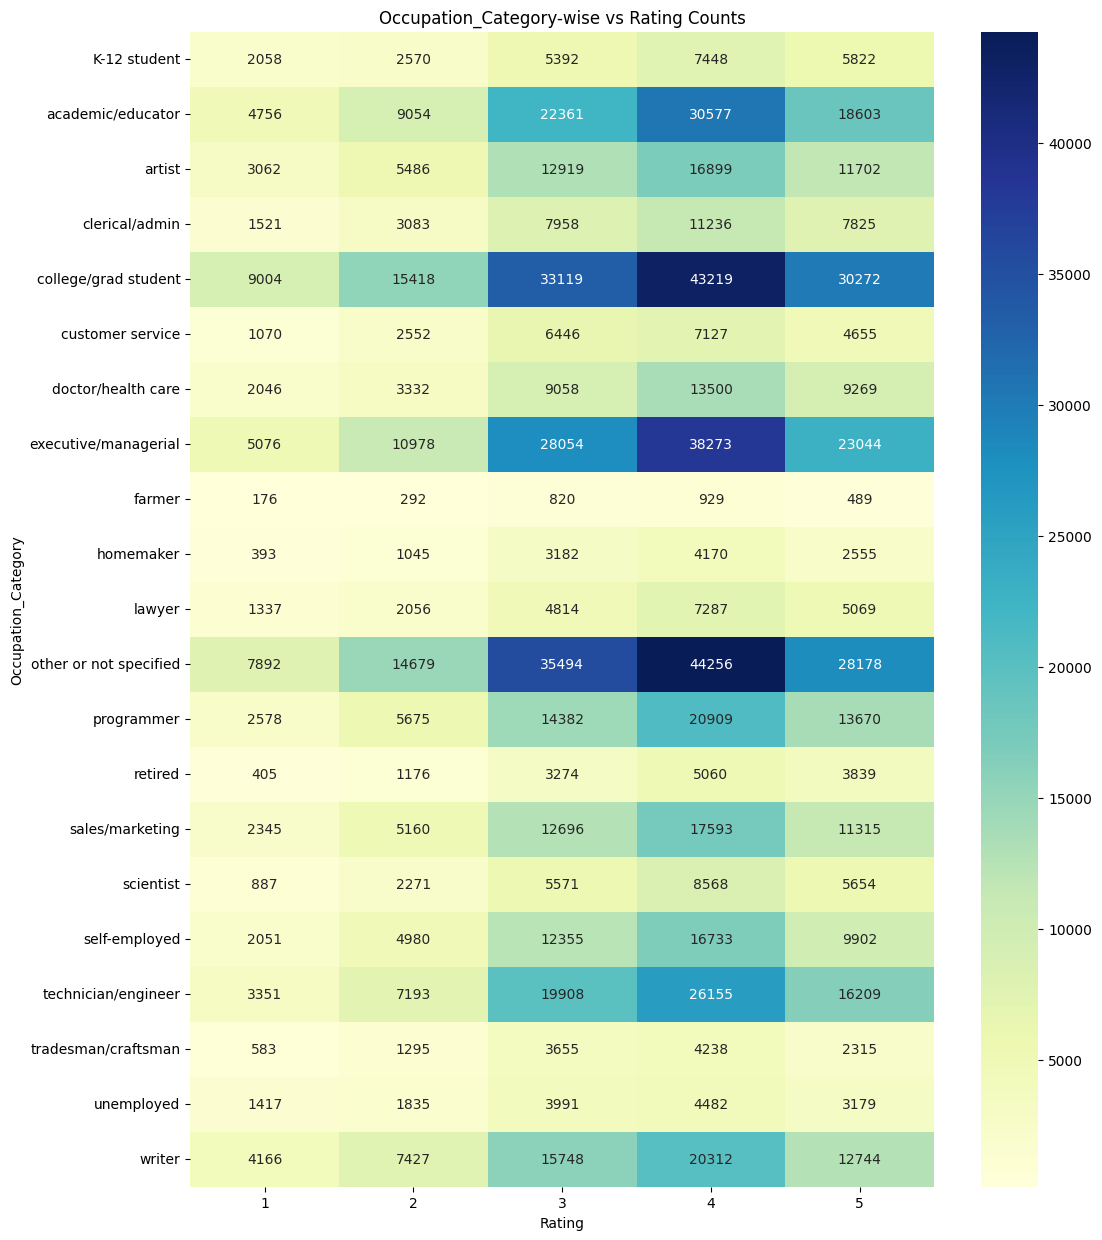

In [79]:
# Occupation_Category vs Rating Count Distribution
Occupation_Category_rating = final_df.groupby(['Rating', 'Occupation_Category']).size().reset_index(name='count')

# Correct pivot syntax using keyword arguments
pivot_table_Occupation_Category = Occupation_Category_rating.pivot_table(index='Occupation_Category', columns='Rating', values='count', fill_value=0)

# Plot heatmap
plt.figure(figsize=(12, 15))
sns.heatmap(pivot_table_Occupation_Category, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Occupation_Category-wise vs Rating Counts')
plt.xlabel('Rating')
plt.ylabel('Occupation_Category')
plt.show()


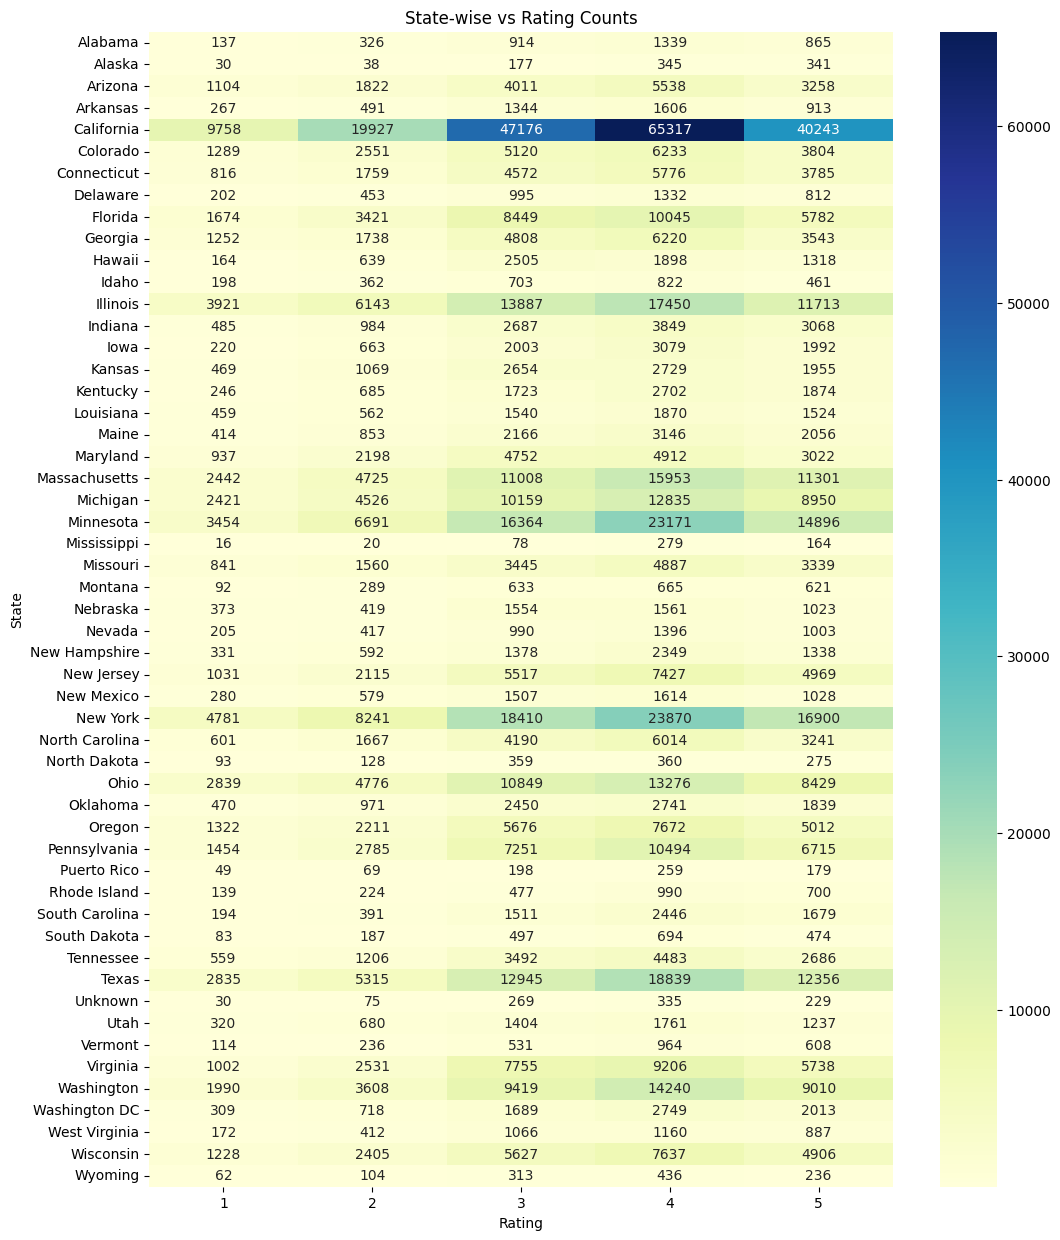

In [80]:
# State vs Rating Count Distribution
State_rating = final_df.groupby(['Rating', 'State']).size().reset_index(name='count')

# Correct pivot syntax using keyword arguments
pivot_table_State = State_rating.pivot_table(index='State', columns='Rating', values='count', fill_value=0)

# Plot heatmap
plt.figure(figsize=(12, 15))
sns.heatmap(pivot_table_State, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('State-wise vs Rating Counts')
plt.xlabel('Rating')
plt.ylabel('State')
plt.show()


**Observations**
> The **gender-wise vs rating counts heatmap** illustrates that **males lead** in rating counts across all values, with the highest at **261,938 ratings for 4 stars**. Among females, the most prominent rating count is **87,033 for 4 stars**, revealing consistent preferences between genders.

> The **heatmap of rating counts by age categories** shows the **25-34 age group leading** in ratings for a score of 4, with a count of **136,824**. In contrast, the **Under 18 category** records the lowest counts, indicating differences in rating behavior across age groups.

> The **heatmap for Genre vs Rating** highlights that **Drama** and **Comedy** genres receive higher ratings in categories 4 and 5. On the other hand, genres like **Documentary** and **Film-Noir** consistently showcase lower rating counts, revealing varying user preferences. 

> The **occupation category-wise rating distribution heatmap** highlights **college/grad students** as leading contributors with over **43,000 ratings for 4 stars**, followed by **academics/educators** and **executive/managerial** categories. Conversely, **farmers have the lowest contribution**, reflecting stark differences across occupations. 

> The **heatmap for state-wise vs rating counts** highlights California as the **most active state**, with over **65,000 ratings for 4 stars**. States like **Mississippi and Alaska** have the **lowest counts**, reflecting regional disparities in user engagement with ratings.
 

## ANOMALY DETECTION

In [96]:
final_df["UserID"].value_counts()

UserID
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
        ... 
708       20
703       20
665       20
2160      20
4749      20
Name: count, Length: 6040, dtype: int64

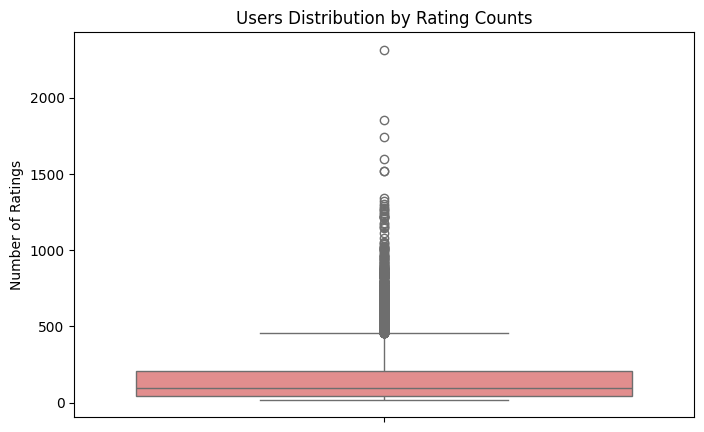

In [95]:
# Boxplot for User Rating Counts
plt.figure(figsize=(8, 5))
sns.boxplot(y=final_df["UserID"].value_counts(), color='lightcoral')
plt.title('Users Distribution by Rating Counts')
plt.ylabel('Number of Ratings')
plt.show()

## TRAIN TEST SPLIT USING TIMESTAMP

In [35]:
# Step 1: Sort data by Timestamp to maintain temporal order
final_df = final_df.sort_values(by='Timestamp').reset_index(drop=True)

# Step 2: Define split points (Train-Test Split Only)
train_size = int(0.8 * len(final_df))  # 80% for training
train_df = final_df.iloc[:train_size]
test_df = final_df.iloc[train_size:]

# Print the shape of each dataset
print(f"Training Set: {train_df.shape}")
print(f"Test Set: {test_df.shape}")

Training Set: (800167, 24)
Test Set: (200042, 24)


In [36]:
print(f"Train Set: {train_df['Timestamp'].min()} to {train_df['Timestamp'].max()}")
print(f"Test Set: {test_df['Timestamp'].min()} to {test_df['Timestamp'].max()}")
print(f"Full Dataset: {final_df['Timestamp'].min()} to {final_df['Timestamp'].max()}")

Train Set: 2000-04-25 23:05:32 to 2000-12-02 14:52:18
Test Set: 2000-12-02 14:52:18 to 2003-02-28 17:49:50
Full Dataset: 2000-04-25 23:05:32 to 2003-02-28 17:49:50


## USER MOVIE INTERACTION MATRICES

### Interaction Matrix for Training Data

In [37]:
# Step 1: Create Pivot Table (NaN for Unrated Entries)
interaction_matrix_train = train_df.pivot_table(index='UserID', columns='MovieID', values='Rating')

# Step 2: Fill with 0 for Cosine Similarity or KNN
interaction_matrix_train_filled = interaction_matrix_train.fillna(0)

# Step 3: Convert to CSR Matrix for CF and Similarity
interaction_csr_train = csr_matrix(interaction_matrix_train_filled.values)

# Step 4: Replace 0 with NaN Before Matrix Factorization
interaction_matrix_train_mf = interaction_matrix_train_filled.replace(0, np.nan)

In [38]:
# Size reduced due to sparsity
interaction_csr_train.shape

(5400, 3662)

In [39]:
interaction_csr_train.data

array([4., 5., 4., ..., 4., 4., 5.], shape=(800167,))

In [40]:
interaction_csr_train.indices

array([ 287,  463,  789, ..., 3454, 3468, 3534],
      shape=(800167,), dtype=int32)

In [41]:
interaction_csr_train.indptr

array([     0,     31,    117, ..., 799726, 799849, 800167],
      shape=(5401,), dtype=int32)

#### Sparsity

In [42]:
sparsity = (interaction_matrix_train_filled>0).sum().sum()/(interaction_matrix_train_filled.shape[0]*interaction_matrix_train_filled.shape[1])
print(f"Sparsity of the User-Movie Matrix: {sparsity}")

Sparsity of the User-Movie Matrix: 0.04046397435119445


**Observation**
> Only 4.04% of cells are filled with non null values in user movie interaction train matrix.

### Interaction Matrix for Test Data

In [43]:
interaction_matrix_test = test_df.pivot_table(index='UserID', columns='MovieID', values='Rating')
interaction_matrix_test_filled = interaction_matrix_test.fillna(0)
interaction_csr_test = csr_matrix(interaction_matrix_test_filled.values)

In [44]:
interaction_csr_test.shape

(1783, 3511)

**Observations**
> No need to get interaction_matrix_test_mf because we will use MF decomposed matrices from train mf to do predictions on validation and test datasets.

# CHAPTER 3: BUILDING RECOMMENDATION SYSTEM BASED ON PEARSON CORRELATION

## ITEM BASED APPROACH

### Item Item Pearson correlation matrix

In [159]:
# Step 1: Compute Item-Item Pearson Correlation on Training Data
item_correlation = interaction_matrix_train.corr(method='pearson')


In [160]:
with open('item_pearson_correlation.pkl', 'wb') as f:
    pickle.dump(item_correlation, f)

In [161]:
item_correlation.head()

MovieID,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
MovieID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.149496,0.180587,0.343797,0.185757,0.059248,0.124951,0.007551,-0.091661,0.138545,...,0.387689,NaN,0.089083,0.076053,2.009535e-01,0.234535,0.115613,0.188982,NaN,0.130005
2,0.149496,1.000000,0.130949,0.098974,0.318844,0.050524,0.231151,0.292840,0.483479,0.252051,...,0.000000,NaN,NaN,0.034586,-8.275114e-17,0.411868,NaN,NaN,NaN,0.308097
3,0.180587,0.130949,1.000000,0.311476,0.458198,0.175268,0.207658,0.511838,0.185726,0.335196,...,-0.102062,1.0,-0.408248,0.111115,2.807999e-01,0.416073,0.144338,NaN,NaN,0.114310
4,0.343797,0.098974,0.311476,1.000000,0.366678,0.065382,0.020908,-0.422577,-0.850000,0.183775,...,0.944911,NaN,NaN,NaN,NaN,0.392081,NaN,NaN,-1.0,0.304290
5,0.185757,0.318844,0.458198,0.366678,1.000000,0.067270,0.323341,0.601929,0.569920,0.220973,...,-1.000000,NaN,NaN,NaN,NaN,0.550655,NaN,NaN,NaN,0.466569


### Function to get similar movies given movie_id

In [162]:
# Step 2: Get Top-N Similar Items
def get_similar_items(movie_id, n=5):
    """Recommend top-n similar movies based on item-item Pearson correlation."""
    if movie_id in item_correlation.columns:
        # Drop NaN and sort by correlation
        similar_items = item_correlation[movie_id].dropna().sort_values(ascending=False)
        
        # Exclude the movie itself
        similar_items = similar_items[similar_items.index != movie_id]
        
        # Get top-n similar movies
        return similar_items.head(n).index.tolist()
    else:
        return []

In [163]:
# Example Usage
movie_id_example = 1  # Replace with any valid Movie ID
movie_title_example = movies.loc[movies['Movie ID'] == movie_id_example, 'Title'].values[0]

# Get top 5 similar movie IDs
similar_movie_ids = get_similar_items(movie_id_example, n=10)

# Map Movie IDs to Titles
similar_movie_titles = movies[movies['Movie ID'].isin(similar_movie_ids)]['Title'].tolist()

# Print results
print(f"Top 5 similar movies to '{movie_title_example}' are:")
for i, title in enumerate(similar_movie_titles, start=1):
    print(f"{i}. {title}")


Top 5 similar movies to 'Toy Story (1995)' are:
1. Killer: A Journal of Murder (1995)
2. Arguing the World (1996)
3. Dear Jesse (1997)
4. Hav Plenty (1997)
5. Trick or Treat (1986)
6. Public Access (1993)
7. Tic Code, The (1998)
8. Catfish in Black Bean Sauce (2000)
9. Under Suspicion (2000)
10. Beautiful (2000)


### rmse and mape metrics

In [49]:
# RMSE Calculation (Directly using sklearn)
def rmse(actual, predicted):
    return root_mean_squared_error(actual, predicted)

# MAPE Calculation (Directly using sklearn)
def mape(actual, predicted):
    return mean_absolute_percentage_error(actual, predicted) * 100

### rating prediction function given user_id and movie_id

In [177]:
def rating_prediction(user_id, movie_id):
    if movie_id not in item_correlation.columns or user_id not in interaction_matrix_train.index:
        return np.nan
    
    user_ratings = interaction_matrix_train.loc[user_id]
    movie_similarity = item_correlation[movie_id]
    
    # Merge ratings with similarity
    rating_similarity = pd.concat([user_ratings, movie_similarity], axis=1, join='inner').dropna()
    rating_similarity.columns = ['UserRating', 'Similarity']

    # Filter only movies rated by the user
    rating_similarity = rating_similarity[rating_similarity['UserRating'] > 0]

    # Weighted sum for prediction
    if len(rating_similarity) == 0:
        return np.nan
    prediction = (rating_similarity['UserRating'] * rating_similarity['Similarity']).sum() / rating_similarity['Similarity'].sum()
    
    return prediction

In [199]:
rating_prediction(635,296)

np.float64(4.222125599789973)

In [ ]:
interaction_matrix_train.index[0]


np.int64(635)

In [198]:
interaction_matrix_train.columns[287]

np.int64(296)

In [195]:
for user_index, movie_index in np.argwhere(~interaction_matrix_train.isna().values):
    user = interaction_matrix_train.index[user_index]
    movie = interaction_matrix_train.columns[movie_index]
    
    pred = rating_prediction(user, movie)
    if pred != np.nan:
        print(user_index,movie_index,pred)
        break

0 287 4.222125599789973


### Calculating the Train metrics rmse and mape by looping over all the non null cells in interaction matrix

In [ ]:
actual_train, predicted_train = [], []

for user_index, movie_index in np.argwhere(~interaction_matrix_train.isna().values):
    user = interaction_matrix_train.index[user_index]
    movie = interaction_matrix_train.columns[movie_index]
    
    pred = rating_prediction(user, movie)
    pred = np.clip(pred, 1, 5)  # Clip predictions between 1 and 5
    
    if not np.isnan(pred):
        actual_train.append(interaction_matrix_train.iloc[user_index, movie_index])
        predicted_train.append(pred)

# Train Metrics
rmse_train = rmse(actual_train, predicted_train)
mape_train = mape(actual_train, predicted_train)


In [194]:
pred

np.float64(3.493595662151264)

In [182]:
print(f'''Train Data Performance for Pearson Correlation Model:
RMSE: {rmse_train:.4f}
MAPE: {mape_train:.2f}%''')

Train Data Performance for Pearson Correlation Model:
RMSE: 0.8427
MAPE: 25.86%


### Calculating the test metrics rmse and mape by looping over all the non null cells in interaction matrix

In [ ]:
actual_test, predicted_test = [], []

for user_index, movie_index in np.argwhere(~interaction_matrix_test.isna().values):
    user = interaction_matrix_test.index[user_index]
    movie = interaction_matrix_test.columns[movie_index]
    
    pred = rating_prediction(user, movie)
    pred = np.clip(pred, 1, 5)
    
    if not np.isnan(pred):
        actual_test.append(interaction_matrix_test.iloc[user_index, movie_index])
        predicted_test.append(pred)

# Test Metrics
rmse_test = rmse(actual_test, predicted_test)
mape_test = mape(actual_test, predicted_test)

In [183]:
print(f'''Test Data Performance for Pearson Correlation Model:
RMSE: {rmse_test:.4f}
MAPE: {mape_test:.2f}%''')

Test Data Performance for Pearson Correlation Model:
RMSE: 1.0530
MAPE: 34.36%


### Final Pearson recommender function to get Top k movie recommendations given a user_id

In [188]:
def pearson_recommender(user_id, num_recommendations=10):
    # Step 1: Get watched movies by the user
    watched_movies = train_df[train_df['UserID'] == user_id]['MovieID'].values

    # Step 2: Get unrated movies for the user
    unrated_movies = item_correlation.columns[~item_correlation.columns.isin(watched_movies)]

    # Step 3: Create an empty dictionary to store recommendations
    suggested_movies = {'MovieID': [], 'Predicted_Rating': []}

    # Step 4: Predict ratings for all unrated movies
    for movie_id in unrated_movies:
        pred = np.clip(rating_prediction(user_id, movie_id), 1, 5)  # Predict rating and clip between 1 and 5
        suggested_movies['MovieID'].append(movie_id)
        suggested_movies['Predicted_Rating'].append(pred)

    # Step 5: Convert suggested_movies to a DataFrame
    suggested_movies_df = pd.DataFrame(suggested_movies)

    # Step 6: Merge with movie titles to display titles in final output
    suggested_movies_df = suggested_movies_df.merge(
        movies[['Movie ID', 'Title']], how='left',left_on="MovieID",right_on="Movie ID"
    )

    # Step 7: Filter movies with predicted rating > 4.5
    if (suggested_movies_df['Predicted_Rating'] > 4.5).sum() < 50:
        suggested_movies_df = (
            suggested_movies_df.sort_values(by='Predicted_Rating', ascending=False)
            .head(50)
            .sample(num_recommendations)
        )
    else:
        suggested_movies_df = (
            suggested_movies_df[suggested_movies_df['Predicted_Rating'] > 4.5]
            .sample(num_recommendations)
        )

    # Step 8: Return the list of recommended movie titles
    return suggested_movies_df['Title'].values


In [ ]:
# Example Usage
user_id_example = 1  # Replace with any valid UserID
num_recommendations = 10  # Number of recommendations

recommended_movies = pearson_recommender(user_id_example, num_recommendations)
print(f"Top {num_recommendations} recommended movies for User {user_id_example}:")
for i, title in enumerate(recommended_movies, start=1):
    print(f"{i}. {title}")


Top 10 recommended movies for User 1:
1. Persuasion (1995)
2. Leaving Las Vegas (1995)
3. Balto (1995)
4. Powder (1995)
5. Father of the Bride Part II (1995)
6. Get Shorty (1995)
7. Dangerous Minds (1995)
8. Nixon (1995)
9. Cutthroat Island (1995)
10. Toy Story (1995)


## USER BASED APPROACH

### User User Pearson Correlation matrix

In [45]:
# Step 1: Compute User-User Pearson Correlation on Training Data
user_correlation = interaction_matrix_train.T.corr(method='pearson')

### Function to Get Top-N Similar Users

In [46]:
def get_similar_users(user_id, n=5):
    """Recommend top-n similar users based on user-user Pearson correlation."""
    if user_id in user_correlation.columns:
        # Drop NaN and sort by correlation
        similar_users = user_correlation[user_id].dropna().sort_values(ascending=False)
        
        # Exclude the user itself
        similar_users = similar_users[similar_users.index != user_id]
        
        # Get top-n similar users
        return similar_users.head(n).index.tolist()
    else:
        return []


###  Predict Ratings for Unseen Movies Using Similar Users

In [47]:
def user_rating_prediction(user_id, movie_id):
    """Predict rating for a movie using user-based collaborative filtering."""
    if user_id not in user_correlation.index or movie_id not in interaction_matrix_train.columns:
        return np.nan
    
    # Get similar users
    similar_users = get_similar_users(user_id, n=5)
    
    # Get ratings by similar users for the given movie
    ratings_by_similar_users = interaction_matrix_train.loc[similar_users, movie_id].dropna()
    
    # Get similarity scores for these users
    similarity_scores = user_correlation.loc[user_id, ratings_by_similar_users.index]
    
    # Weighted sum for prediction
    if len(ratings_by_similar_users) == 0:
        return np.nan
    
    prediction = np.dot(ratings_by_similar_users.values, similarity_scores.values) / np.abs(similarity_scores.values).sum()
    
    return prediction


### Evaluate Train and Test Metrics

In [51]:
# Evaluate User-Based Model Performance on Training Data
actual_train, predicted_train = [], []

for user_index, movie_index in np.argwhere(~interaction_matrix_train.isna().values):
    user = interaction_matrix_train.index[user_index]
    movie = interaction_matrix_train.columns[movie_index]
    
    pred = user_rating_prediction(user, movie)
    pred = np.clip(pred, 1, 5)  # Clip predictions to range [1, 5]
    
    if not np.isnan(pred):
        actual_train.append(interaction_matrix_train.iloc[user_index, movie_index])
        predicted_train.append(pred)

# Train Metrics
rmse_train = rmse(actual_train, predicted_train)
mape_train = mape(actual_train, predicted_train)

print(f'User-Based CF RMSE on Training Data: {rmse_train:.4f}')
print(f'User-Based CF MAPE on Training Data: {mape_train:.2f}%')


User-Based CF RMSE on Training Data: 1.1029
User-Based CF MAPE on Training Data: 28.58%


In [ ]:
# Evaluate User-Based Model Performance
actual_test, predicted_test = [], []

for user_index, movie_index in np.argwhere(~interaction_matrix_test.isna().values):
    user = interaction_matrix_test.index[user_index]
    movie = interaction_matrix_test.columns[movie_index]
    
    pred = user_rating_prediction(user, movie)
    pred = np.clip(pred, 1, 5)
    
    if not np.isnan(pred):
        actual_test.append(interaction_matrix_test.iloc[user_index, movie_index])
        predicted_test.append(pred)

In [50]:
# Test Metrics
rmse_test = rmse(actual_test, predicted_test)
mape_test = mape(actual_test, predicted_test)

print(f'User-Based CF RMSE on Test Data: {rmse_test:.4f}')
print(f'User-Based CF MAPE on Test Data: {mape_test:.2f}%')


User-Based CF RMSE on Test Data: 1.3088
User-Based CF MAPE on Test Data: 34.47%


### Generate Recommendations Using User-Based Approach

In [54]:
def user_pearson_recommender(user_id, num_recommendations=10):
    # Step 1: Get watched movies by the user
    watched_movies = train_df[train_df['UserID'] == user_id]['MovieID'].values

    # Step 2: Get unrated movies for the user
    unrated_movies = user_correlation.columns[~user_correlation.columns.isin(watched_movies)]

    # Step 3: Create an empty dictionary to store recommendations
    suggested_movies = {'MovieID': [], 'Predicted_Rating': []}

    # Step 4: Predict ratings for all unrated movies
    for movie_id in unrated_movies:
        pred = np.clip(user_rating_prediction(user_id, movie_id), 1, 5)  # Predict rating and clip between 1 and 5
        if not np.isnan(pred):
            suggested_movies['MovieID'].append(movie_id)
            suggested_movies['Predicted_Rating'].append(pred)

    # Step 5: Convert suggested_movies to a DataFrame
    suggested_movies_df = pd.DataFrame(suggested_movies)

    # Step 6: Merge with movie titles to display titles in final output
    suggested_movies_df = suggested_movies_df.merge(
        movies[['Movie ID', 'Title']], how='left', left_on="MovieID", right_on="Movie ID"
    ).drop(columns=['Movie ID'])

    # Step 7: Check if suggested_movies_df is empty or has fewer recommendations than required
    if suggested_movies_df.empty:
        print(f"No recommendations found for User {user_id}.")
        return []

    if len(suggested_movies_df) < num_recommendations:
        print(f"Only {len(suggested_movies_df)} movies available for User {user_id}. Showing all available movies.")
        num_recommendations = len(suggested_movies_df)

    # Step 8: Filter and sample movies
    if (suggested_movies_df['Predicted_Rating'] > 4.5).sum() < 50:
        suggested_movies_df = (
            suggested_movies_df.sort_values(by='Predicted_Rating', ascending=False)
            .head(50)
            .sample(num_recommendations, random_state=42)
        )
    else:
        suggested_movies_df = (
            suggested_movies_df[suggested_movies_df['Predicted_Rating'] > 4.5]
            .sample(num_recommendations, random_state=42)
        )

    # Step 9: Return the list of recommended movie titles
    return suggested_movies_df['Title'].values


In [56]:
# Example Usage
user_id_example = 1000  # Replace with any valid UserID
num_recommendations = 10  # Number of recommendations

recommended_movies = user_pearson_recommender(user_id_example, num_recommendations)
print(f"Top {num_recommendations} recommended movies for User {user_id_example}:")
for i, title in enumerate(recommended_movies, start=1):
    print(f"{i}. {title}")


Top 10 recommended movies for User 1000:
1. After Life (1998)
2. Women, The (1939)
3. Eyes Wide Shut (1999)
4. Grifters, The (1990)
5. Nowhere (1997)
6. Modern Times (1936)
7. Yojimbo (1961)
8. Player, The (1992)
9. Magnolia (1999)
10. Paths of Glory (1957)


# CHAPTER 4: BUILDING RECOMMENDATION SYSTEM BASED ON KNN AND COSINE SIMILARITY

## COSINE SIMILARITY MATRICES

In [202]:
# Step 5: Compute Cosine Similarity
item_cosine_sim = cosine_similarity(interaction_csr_train.T)  # Item-Item Cosine Similarity
user_cosine_sim = cosine_similarity(interaction_csr_train)    # User-User Cosine Similarity

# Convert to DataFrame for easier handling
item_cosine_sim_df = pd.DataFrame(item_cosine_sim, index=interaction_matrix_train.columns, columns=interaction_matrix_train.columns)
user_cosine_sim_df = pd.DataFrame(user_cosine_sim, index=interaction_matrix_train.index, columns=interaction_matrix_train.index)

print("Item-Item Cosine Similarity Matrix and User-User Similarity Matrix are Created!")

Item-Item Cosine Similarity Matrix and User-User Similarity Matrix are Created!


In [204]:
item_cosine_sim_df.head()

MovieID,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
MovieID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.364420,0.249381,0.163734,0.236371,0.328844,0.274959,0.109440,0.091072,0.353560,...,0.056681,0.003993,0.064875,0.050901,0.023064,0.196753,0.039668,0.014767,0.001214,0.084854
2,0.364420,1.000000,0.226099,0.137198,0.224101,0.237444,0.241995,0.170421,0.149971,0.382878,...,0.026315,0.000000,0.027585,0.074852,0.041678,0.126606,0.029434,0.000000,0.006081,0.056319
3,0.249381,0.226099,1.000000,0.171534,0.283433,0.175323,0.281483,0.085707,0.109610,0.216027,...,0.020528,0.047883,0.037026,0.065290,0.048240,0.134817,0.035240,0.012256,0.008566,0.064931
4,0.163734,0.137198,0.171534,1.000000,0.266108,0.124579,0.213957,0.042660,0.047786,0.119420,...,0.030587,0.079518,0.000000,0.006554,0.000000,0.075792,0.019507,0.006920,0.019346,0.036496
5,0.236371,0.224101,0.283433,0.266108,1.000000,0.132231,0.284276,0.104101,0.125342,0.196911,...,0.022054,0.072624,0.023867,0.033669,0.014807,0.098063,0.004276,0.000000,0.006626,0.044695


In [205]:
user_cosine_sim_df.head()

UserID,635,636,637,638,639,640,641,642,643,644,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
UserID,,,,,,,,,,,,,,,,,,,,,
635,1.000000,0.026691,0.088451,0.018037,0.024692,0.040129,0.104878,0.029727,0.033338,0.069651,...,0.029313,0.022752,0.055143,0.000000,0.084872,0.086303,0.113756,0.027969,0.048921,0.133877
636,0.026691,1.000000,0.174665,0.170987,0.157088,0.000000,0.020390,0.131076,0.021000,0.126666,...,0.111710,0.047174,0.183838,0.000000,0.213842,0.192785,0.125157,0.046980,0.069927,0.090936
637,0.088451,0.174665,1.000000,0.235314,0.230834,0.046894,0.189858,0.100528,0.052834,0.111137,...,0.152505,0.247358,0.214006,0.060986,0.165909,0.354850,0.291603,0.070144,0.166865,0.264876
638,0.018037,0.170987,0.235314,1.000000,0.170137,0.026690,0.087494,0.073155,0.060311,0.132101,...,0.243314,0.080705,0.125949,0.039858,0.127226,0.182618,0.117020,0.068208,0.068578,0.186783
639,0.024692,0.157088,0.230834,0.170137,1.000000,0.065769,0.021692,0.124507,0.173628,0.154658,...,0.200709,0.087696,0.401663,0.045211,0.133153,0.212165,0.116557,0.025466,0.049340,0.102460


In [212]:
with open("item_cosine_sim_df.pkl","wb") as file:
    pickle.dump(item_cosine_sim_df,file)

with open("user_cosine_sim_df.pkl","wb") as file:
    pickle.dump(user_cosine_sim_df,file)


## KNN FITTING ON ITEM VECTORS

In [214]:
# Initialize KNN Model for Item-Item CF
item_knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20, n_jobs=-1)

# Fit Model on CSR Matrix (Transpose for Item-Item)
item_knn_model.fit(interaction_csr_train.T)

print("KNN Model for Item-Item Collaborative Filtering is Fitted!")

KNN Model for Item-Item Collaborative Filtering is Fitted!


## KNN RECOMMENDATION FUNCTION

In [218]:
def get_knn_recommendations(movie_id, n=5):
    """Get top-n movie recommendations using KNN based on cosine similarity."""
    
    if movie_id not in interaction_matrix_train.columns:
        return f"Movie ID {movie_id} not found in the training data."
    
    # Get the index of the movie in the matrix
    movie_idx = interaction_matrix_train.columns.get_loc(movie_id)
    
    # Find k-nearest neighbors (excluding itself)
    distances, indices = item_knn_model.kneighbors(interaction_csr_train.T[movie_idx], n_neighbors=n+1)
    
    # Get similar movie IDs (exclude the first item, which is the queried movie itself)
    similar_movie_ids = interaction_matrix_train.columns[indices.flatten()][1:n+1]
    
    # Map movie IDs to Titles
    similar_movie_titles = movies[movies['Movie ID'].isin(similar_movie_ids)]['Title'].tolist()
    
    return similar_movie_titles

In [222]:
movie_id_example = 1  # Replace with a valid MovieID

# Get the movie name for the given Movie ID
movie_title_example = movies.loc[movies['Movie ID'] == movie_id_example, 'Title'].values[0]

recommended_movies = get_knn_recommendations(movie_id_example, n=10)

print(f"Top 5 movies similar to '{movie_title_example}' are:")
for i, title in enumerate(recommended_movies, start=1):
    print(f"{i}. {title}")


Top 5 movies similar to 'Toy Story (1995)' are:
1. Babe (1995)
2. Forrest Gump (1994)
3. Aladdin (1992)
4. Star Wars: Episode V - The Empire Strikes Back (1980)
5. Groundhog Day (1993)
6. Back to the Future (1985)
7. Men in Black (1997)
8. Bug's Life, A (1998)
9. Matrix, The (1999)
10. Toy Story 2 (1999)


## EVALUATE TRAIN AND TEST DATASET 

In [223]:
def predict_knn_rating(user_id, movie_id, n_neighbors=5):
    """Predict rating using KNN similarity."""
    if movie_id not in interaction_matrix_train.columns or user_id not in interaction_matrix_train.index:
        return np.nan
    
    # Get similar movies based on item-item similarity
    similar_movies = item_cosine_sim_df[movie_id].sort_values(ascending=False).drop(movie_id).head(n_neighbors)
    
    # Get the user's ratings for these movies
    user_ratings = interaction_matrix_train.loc[user_id, similar_movies.index]
    
    # Filter movies that the user has rated
    valid_ratings = user_ratings[user_ratings > 0]
    
    # If no valid ratings, return NaN
    if len(valid_ratings) == 0:
        return np.nan
    
    # Weighted average of ratings with similarity as weights
    prediction = np.dot(valid_ratings, similar_movies.loc[valid_ratings.index]) / similar_movies.loc[valid_ratings.index].sum()
    
    return prediction


In [226]:
actual_train = []
predicted_train = []

# Iterate over non-zero train ratings
for user_index, movie_index in np.argwhere(interaction_matrix_train_filled > 0):
    user_id = interaction_matrix_train.index[user_index]
    movie_id = interaction_matrix_train.columns[movie_index]
    
    # Predict rating using KNN
    pred = predict_knn_rating(user_id, movie_id, n_neighbors=5)
    pred = np.clip(pred, 1, 5)
    
    # Append to lists if prediction is valid
    if not np.isnan(pred):
        actual_train.append(interaction_matrix_train.iloc[user_index, movie_index])
        predicted_train.append(pred)

# Compute RMSE and MAPE for train data
rmse_knn_train = rmse(actual_train, predicted_train)
mape_knn_train = mape(actual_train, predicted_train)

print(f"Train Data Performance for KNN-Cosine Similarity Model:")
print(f"RMSE: {rmse_knn_train:.4f}")
print(f"MAPE: {mape_knn_train:.2f}%")


Train Data Performance for KNN-Cosine Similarity Model:
RMSE: 0.9963
MAPE: 28.51%


In [224]:
actual_test = []
predicted_test = []

# Iterate over non-zero test ratings
for user_index, movie_index in np.argwhere(interaction_matrix_test_filled > 0):
    user_id = interaction_matrix_test.index[user_index]
    movie_id = interaction_matrix_test.columns[movie_index]
    
    # Predict rating using KNN
    pred = predict_knn_rating(user_id, movie_id, n_neighbors=5)
    pred = np.clip(pred, 1, 5)
    
    # Append to lists if prediction is valid
    if not np.isnan(pred):
        actual_test.append(interaction_matrix_test.iloc[user_index, movie_index])
        predicted_test.append(pred)

# Compute RMSE and MAPE
rmse_knn = rmse(actual_test, predicted_test)
mape_knn = mape(actual_test, predicted_test)

print(f"Test Data Performance for KNN-Cosine Similarity Model:")
print(f"RMSE: {rmse_knn:.4f}")
print(f"MAPE: {mape_knn:.2f}%")


Test Data Performance for KNN-Cosine Similarity Model:
RMSE: 1.1314
MAPE: 33.47%


## FINAL KNN COSINE RECOMMENDER FUNCTION

In [251]:
# Calculate Average Rating per Movie
average_ratings = final_df.groupby('MovieID')['Rating'].mean().reset_index()
average_ratings.columns = ['Movie ID', 'AverageRating']

# Merge with movies DataFrame
movies = movies.merge(average_ratings, on='Movie ID', how='left')
print("Average ratings successfully merged with movies data!")


Average ratings successfully merged with movies data!


In [267]:
# Corrected KNN-Cosine Recommender
def knn_cosine_recommender(user_id, n=10):
    """Recommend top-n movies for a user using User-User KNN with Cosine Similarity."""
    
    # Check if user_id exists in the interaction matrix
    if user_id not in interaction_matrix_train.index:
        print(f"User {user_id} not found in training data.")
        return []
    
    # Get similarity scores for the user, drop self-similarity
    user_sim_scores = user_cosine_sim_df[user_id].drop(user_id).sort_values(ascending=False)
    
    # Get movies already rated by the user
    user_rated_movies = interaction_matrix_train.loc[user_id]
    rated_movie_ids = user_rated_movies[user_rated_movies > 0].index.tolist()
    
    # Initialize DataFrame for weighted ratings
    weighted_ratings = pd.DataFrame(0, index=interaction_matrix_train.columns, columns=['Weighted_Rating', 'Sum_Similarity'])
    
    # Iterate through top-k similar users
    for similar_user in user_sim_scores.index[:10]:  # Top 10 similar users
        # Get ratings by the similar user
        sim_user_ratings = interaction_matrix_train.loc[similar_user]
        
        # Get similarity score with target user
        sim_score = user_sim_scores[similar_user]
        
        # Get unrated movies only
        unrated_movies = sim_user_ratings[sim_user_ratings > 0].index.difference(rated_movie_ids)
        
        # Update weighted ratings and sum of similarities for unrated movies
        weighted_ratings.loc[unrated_movies, 'Weighted_Rating'] += sim_user_ratings[unrated_movies] * sim_score
        weighted_ratings.loc[unrated_movies, 'Sum_Similarity'] += sim_score
    
    # Calculate predicted ratings only for unrated movies
    weighted_ratings['Predicted_Rating'] = weighted_ratings['Weighted_Rating'] / weighted_ratings['Sum_Similarity']
    
    # Drop NaN values due to division by zero
    predicted_movies = weighted_ratings.dropna(subset=['Predicted_Rating'])
    
    # Sort predictions by predicted rating
    predicted_movies = predicted_movies.sort_values(by='Predicted_Rating', ascending=False)
    
    # Check if valid recommendations exist
    if predicted_movies.empty:
        print(f"No valid recommendations for User {user_id}. Using fallback recommendations.")
        # Use fallback recommendations from most highly rated movies
        top_movies = movies.sort_values(by='AverageRating', ascending=False).head(n)['Title'].tolist()
        return top_movies
    
    # Get top-n recommended movie IDs
    top_movie_ids = predicted_movies.index[:n].tolist()
    
    # Map movie IDs to titles for final recommendation
    recommended_movies = movies[movies['Movie ID'].isin(top_movie_ids)]['Title'].tolist()
    
    return recommended_movies


In [ ]:
# Get recommendations for a sample user
user_id_example = 1000 # Replace with any valid UserID
num_recommendations = 10  # Number of recommendations

# Get movie recommendations
recommended_movies = knn_cosine_recommender(user_id_example, num_recommendations)

# Print recommendations
print(f"Top {num_recommendations} recommended movies for User {user_id_example}:")
if recommended_movies:
    for i, title in enumerate(recommended_movies, start=1):
        print(f"{i}. {title}")
else:
    print(f"No valid recommendations for User {user_id_example}.")

Top 10 recommended movies for User 1000:
1. Much Ado About Nothing (1993)
2. Some Like It Hot (1959)
3. Sleeper (1973)
4. Annie Hall (1977)
5. Glory (1989)
6. Cyrano de Bergerac (1990)
7. Young Frankenstein (1974)
8. Ghostbusters (1984)
9. Lolita (1962)
10. Ferris Bueller's Day Off (1986)


# CHAPTER 5: BUILDING RECOMMENDATION SYSTEM USING MATRIX FACTORIZATION

## BUILD ALS CMFREC MODEL

In [43]:
# Use the correct matrix with NaN values for MF
train_matrix_np = interaction_matrix_train_mf.values

# Define user and movie mappings
user_mapping = dict(enumerate(interaction_matrix_train_mf.index))
movie_mapping = dict(enumerate(interaction_matrix_train_mf.columns))

In [44]:
# Define CMF Model with ALS (Fixed)
als_model = CMF(k=20,                # Number of latent factors
                method='als',        # Use ALS for matrix factorization
                niter=20,            # Number of iterations
                verbose=False,        # Show training progress
                random_state=42)     # Set random seed for reproducibility

# Fit ALS Model to Training Data
als_model.fit(train_matrix_np)

print("✅ ALS Model using CMF has been trained successfully!")


✅ ALS Model using CMF has been trained successfully!


## TSNE VISUALISATION OF EMBEDDINGS

In [295]:
# Extract User and Item Embeddings from ALS Model
user_embeddings = als_model.A_  # Shape: (num_users, k)
item_embeddings = als_model.B_  # Shape: (num_items, k)

print(f"User Embeddings Shape: {user_embeddings.shape}")
print(f"Item Embeddings Shape: {item_embeddings.shape}")


User Embeddings Shape: (5400, 20)
Item Embeddings Shape: (3662, 20)


In [314]:
# Apply t-SNE to User Embeddings
tsne_user = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=10000)
user_embeddings_2d = tsne_user.fit_transform(user_embeddings)

# Apply t-SNE to Item Embeddings
tsne_item = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=10000)
item_embeddings_2d = tsne_item.fit_transform(item_embeddings)

print("t-SNE completed for User and Item Embeddings.")


t-SNE completed for User and Item Embeddings.


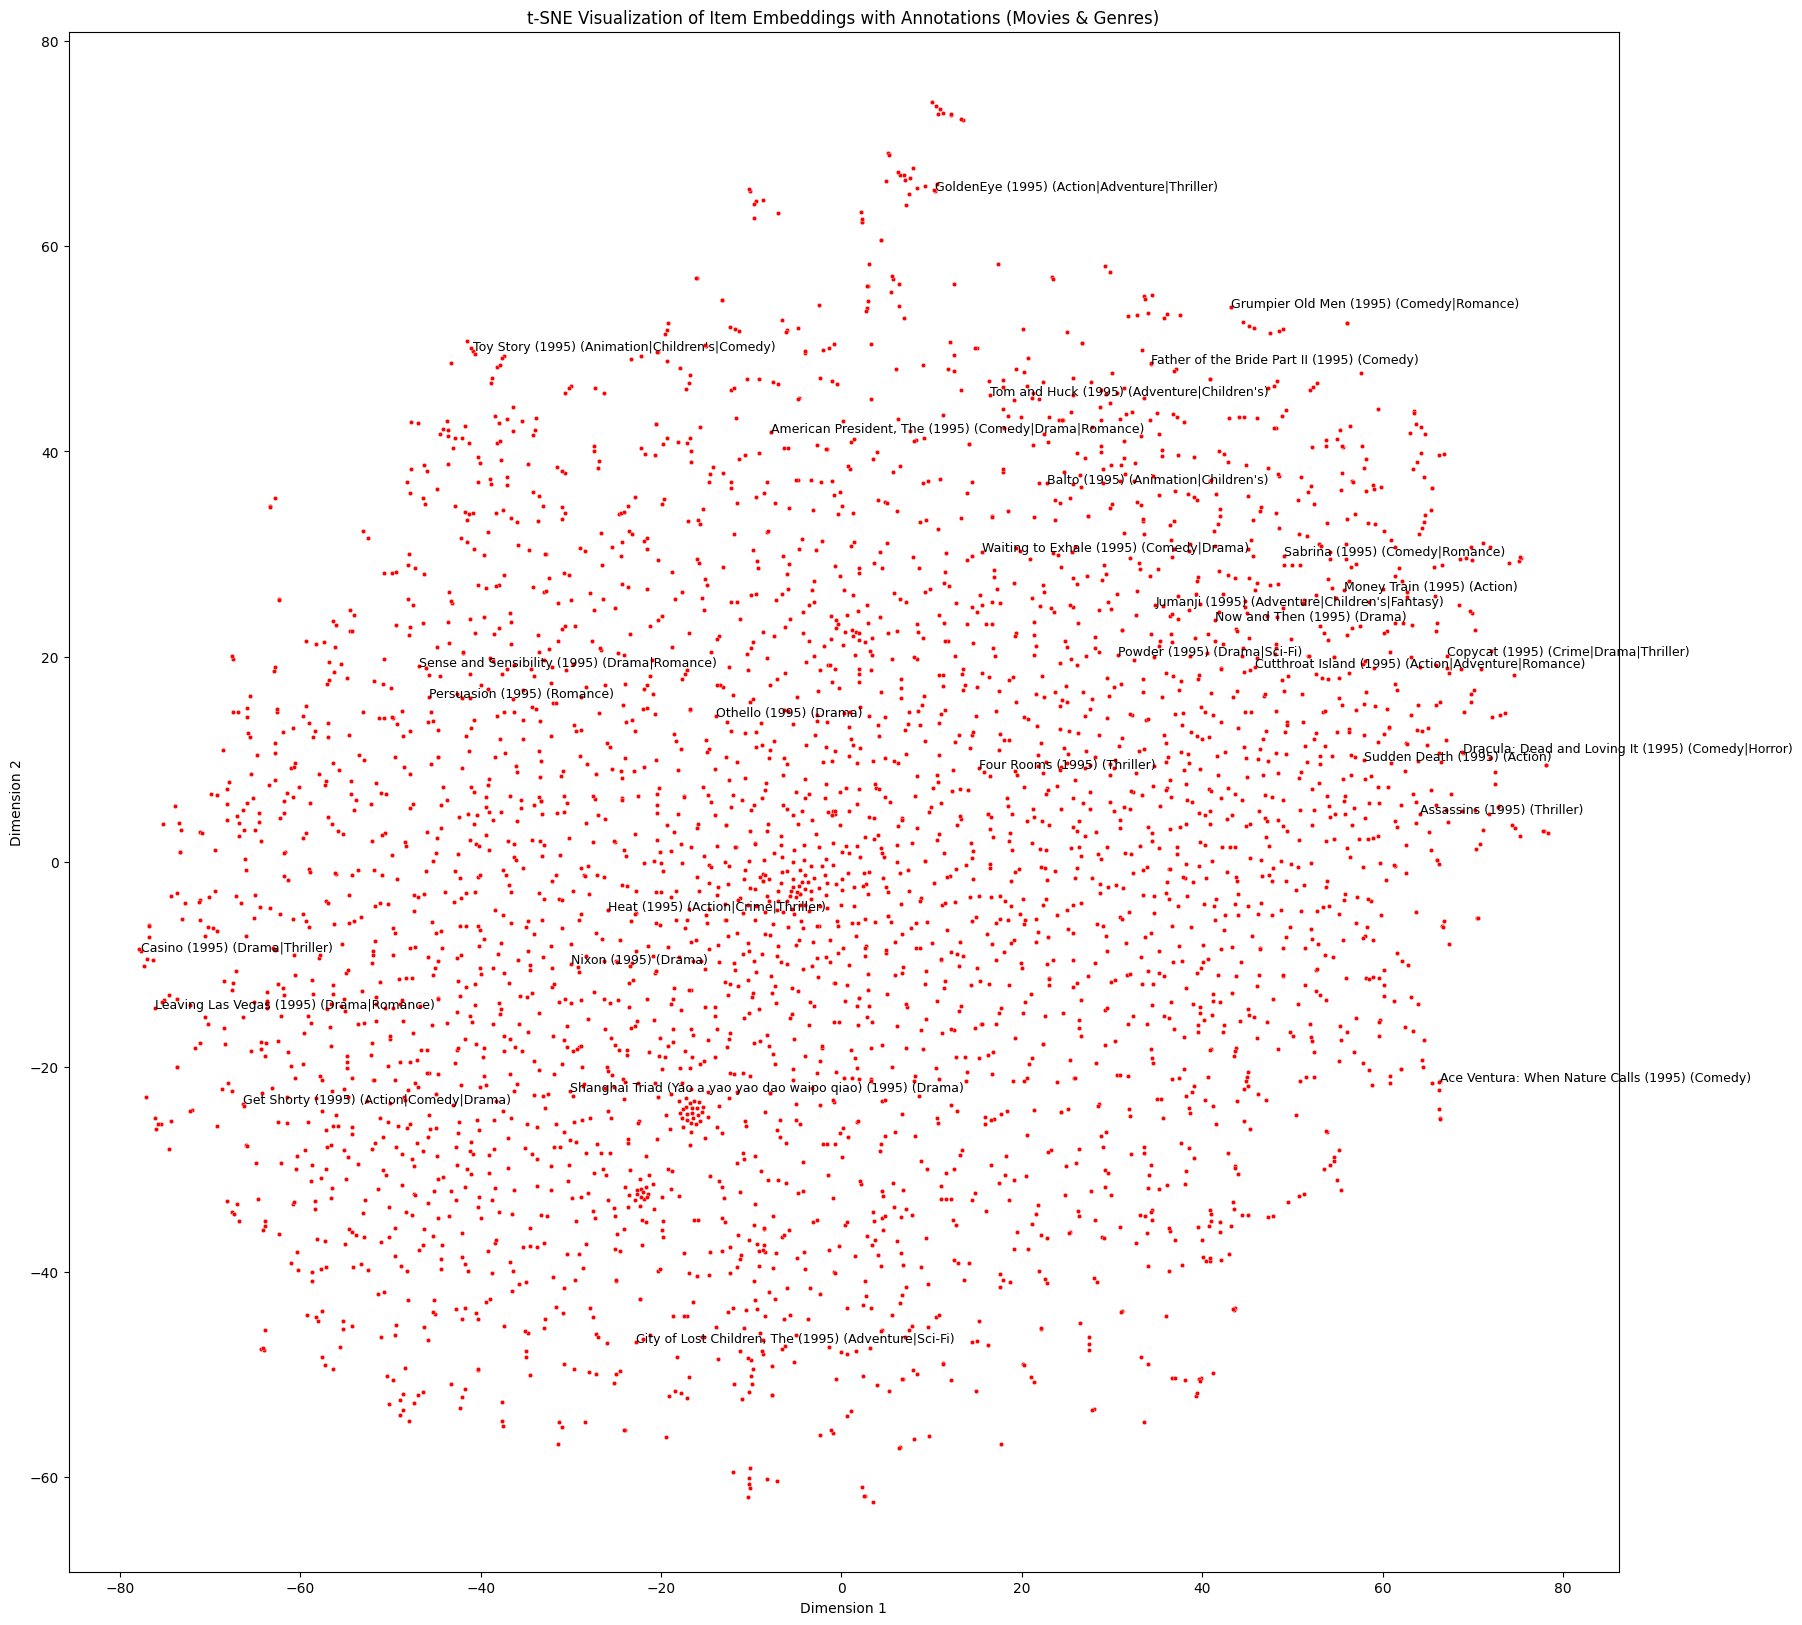

In [315]:
# Annotate top 30 items (movies) with genres
plt.figure(figsize=(20, 20))
sns.scatterplot(x=item_embeddings_2d[:, 0], y=item_embeddings_2d[:, 1], s=10, color='red')

# Annotate top 30 movies
for i, row in movies.head(30).iterrows():
    title = row['Title']
    genres = row['Genres']
    annotation_text = f"{title} ({genres})"
    plt.annotate(annotation_text, (item_embeddings_2d[i, 0], item_embeddings_2d[i, 1]), fontsize=9)

plt.title('t-SNE Visualization of Item Embeddings with Annotations (Movies & Genres)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()


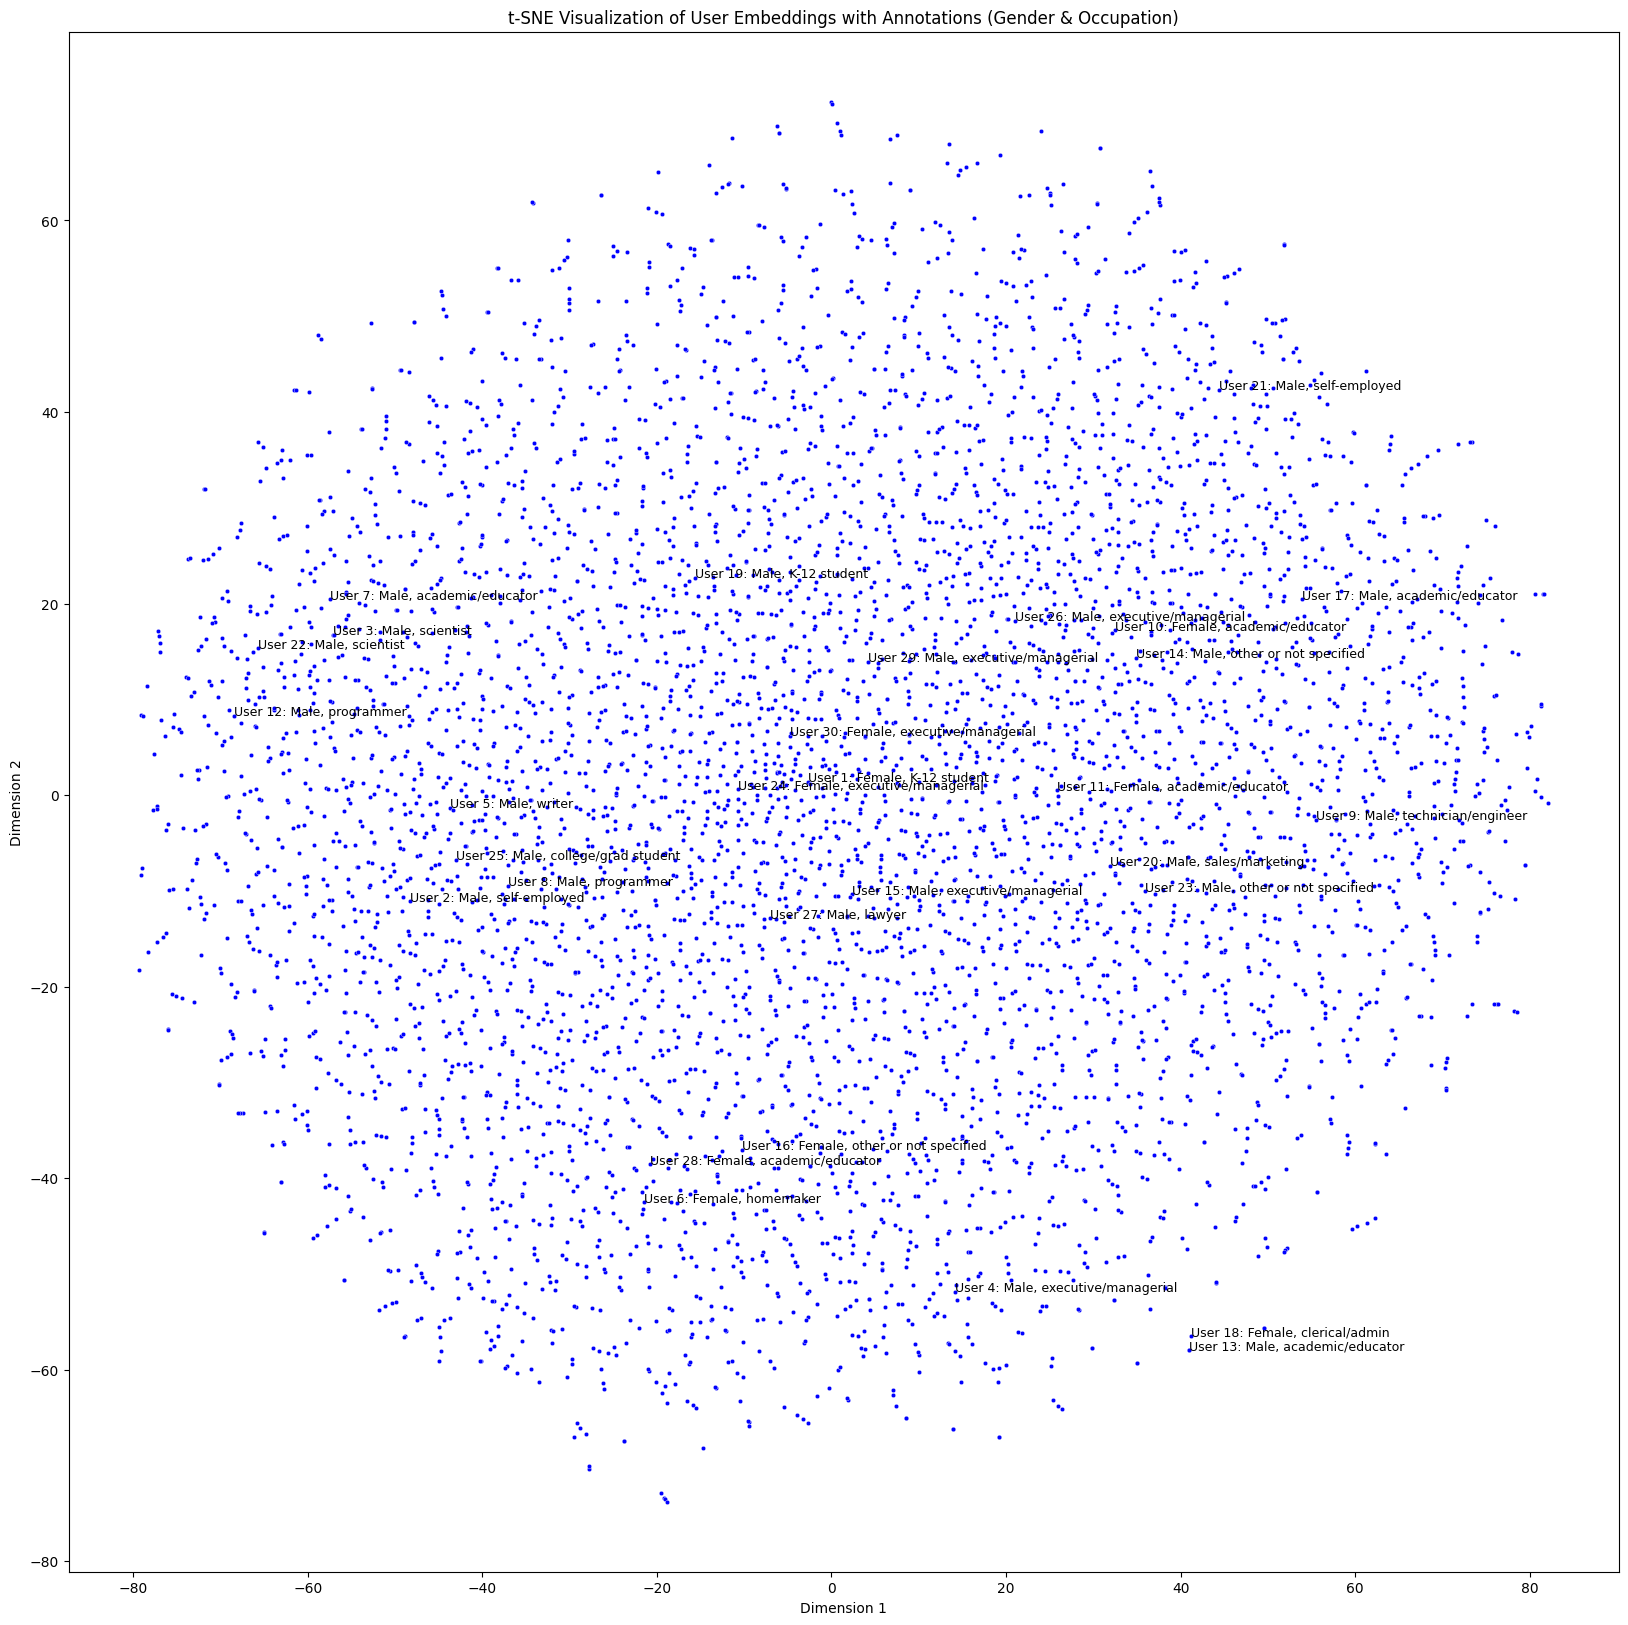

In [316]:
# Annotate top 30 users with gender and occupation
plt.figure(figsize=(20, 20))
sns.scatterplot(x=user_embeddings_2d[:, 0], y=user_embeddings_2d[:, 1], s=10, color='blue')

# Annotate top 30 users
for i, row in users.head(30).iterrows():
    user_id = row['UserID']
    gender = row['Gender']
    occupation = row['Occupation_Category']
    annotation_text = f"User {user_id}: {gender}, {occupation}"
    plt.annotate(annotation_text, (user_embeddings_2d[i, 0], user_embeddings_2d[i, 1]), fontsize=9)

plt.title('t-SNE Visualization of User Embeddings with Annotations (Gender & Occupation)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()


## PREDICT ALS RATING

In [45]:
def predict_als_rating(user_id, movie_id):
    """Predict the rating using ALS model."""
    # Check if user_id and movie_id exist in the matrix
    if user_id not in interaction_matrix_train_mf.index or movie_id not in interaction_matrix_train_mf.columns:
        return np.nan
    
    # Get ALS matrix indices
    user_idx = interaction_matrix_train_mf.index.get_loc(user_id)
    movie_idx = interaction_matrix_train_mf.columns.get_loc(movie_id)
    
    # Predict rating using ALS
    pred_rating = als_model.predict(user=user_idx, item=movie_idx)
    
    return np.clip(pred_rating, 1, 5)


## EVALUATE TRAIN AND TEST METRICS USING ALS RATING METHOD

In [285]:
actual_train = []
predicted_train = []

# Iterate over non-zero train ratings
for user_index, movie_index in np.argwhere(~np.isnan(train_matrix_np)):
    user_id = interaction_matrix_train_mf.index[user_index]
    movie_id = interaction_matrix_train_mf.columns[movie_index]
    
    # Predict rating using ALS
    pred = predict_als_rating(user_id, movie_id)
    
    # Append valid predictions
    if not np.isnan(pred):
        actual_train.append(interaction_matrix_train_mf.iloc[user_index, movie_index])
        predicted_train.append(pred)

# Compute RMSE and MAPE for train data
rmse_als_train = rmse(actual_train, predicted_train)
mape_als_train = mape(actual_train, predicted_train)

print(f"Train Data Performance for ALS Model:")
print(f"RMSE: {rmse_als_train:.4f}")
print(f"MAPE: {mape_als_train:.2f}%")


Train Data Performance for ALS Model:
RMSE: 0.7232
MAPE: 21.62%


In [286]:
actual_test = []
predicted_test = []

# Iterate over non-zero test ratings
for user_index, movie_index in np.argwhere(interaction_matrix_test_filled > 0):
    user_id = interaction_matrix_test.index[user_index]
    movie_id = interaction_matrix_test.columns[movie_index]
    
    # Predict rating using ALS
    pred = predict_als_rating(user_id, movie_id)
    
    # Append valid predictions
    if not np.isnan(pred):
        actual_test.append(interaction_matrix_test.iloc[user_index, movie_index])
        predicted_test.append(pred)

# Compute RMSE and MAPE for test data
rmse_als = rmse(actual_test, predicted_test)
mape_als = mape(actual_test, predicted_test)

print(f"Test Data Performance for ALS Model:")
print(f"RMSE: {rmse_als:.4f}")
print(f"MAPE: {mape_als:.2f}%")


Test Data Performance for ALS Model:
RMSE: 0.8901
MAPE: 28.06%


## MF - ALS RECOMMENDER FUNCTION

In [46]:
def als_recommender(user_id, n=10):
    """Generate top-n movie recommendations using ALS."""
    
    # Check if user_id exists in the interaction matrix
    if user_id not in interaction_matrix_train_mf.index:
        print(f"User {user_id} not found in training data.")
        return []
    
    # Get user index in the matrix
    user_idx = interaction_matrix_train_mf.index.get_loc(user_id)
    
    # Predict ratings for all movies for the given user
    pred_ratings = als_model.predict(
        user=np.repeat(user_idx, len(interaction_matrix_train_mf.columns)),  # Repeat to match shape
        item=np.arange(len(interaction_matrix_train_mf.columns))  # Movie indices
    )
    
    # Create DataFrame for predicted ratings
    pred_ratings_df = pd.DataFrame({'MovieID': interaction_matrix_train_mf.columns, 'Predicted_Rating': pred_ratings})
    
    # Get movies already rated by the user
    rated_movie_ids = interaction_matrix_train_mf.loc[user_id].dropna().index.tolist()
    
    # Filter out movies already rated by the user
    pred_ratings_df = pred_ratings_df[~pred_ratings_df['MovieID'].isin(rated_movie_ids)]
    
    # Get top-n movies based on predicted ratings
    top_movies = pred_ratings_df.sort_values(by='Predicted_Rating', ascending=False).head(n)
    
    # Map Movie IDs to Titles for final recommendations
    recommended_movies = movies[movies['Movie ID'].isin(top_movies['MovieID'])]['Title'].tolist()
    
    return recommended_movies


In [294]:
# Get recommendations for a sample user
user_id_example = 635  # Replace with any valid UserID
num_recommendations = 10  # Number of recommendations

recommended_movies = als_recommender(user_id_example, num_recommendations)

# Print recommendations
print(f"Top {num_recommendations} recommended movies for User {user_id_example}:")
for i, title in enumerate(recommended_movies, start=1):
    print(f"{i}. {title}")


Top 10 recommended movies for User 635:
1. Shawshank Redemption, The (1994)
2. Schindler's List (1993)
3. Close Shave, A (1995)
4. Rear Window (1954)
5. Monty Python and the Holy Grail (1974)
6. Wrong Trousers, The (1993)
7. One Flew Over the Cuckoo's Nest (1975)
8. Saving Private Ryan (1998)
9. Life Is Beautiful (La Vita è bella) (1997)
10. Sanjuro (1962)


# CHAPTER 6: RESULTS, ACTIONABLE INSIGHTS AND RECOMMENDATIONS

## **Performance Comparison of Recommendation Models**

---

### **Model Evaluation Metrics**

| Model                           | Similarity/Approach   | Data Split | RMSE  | MAPE (%) |
|----------------------------------|-----------------------|------------|-------|----------|
| Pearson Correlation (Item-Based) | Pearson (Item)        | Train      | 0.8427 | 25.86    |
| Pearson Correlation (Item-Based) | Pearson (Item)        | Test       | 1.0530 | 34.36    |
| Pearson Correlation (User-Based) | Pearson (User)        | Train      | 1.1029 | 28.58    |
| Pearson Correlation (User-Based) | Pearson (User)        | Test       | 1.3088 | 34.47    |
| KNN-Cosine Similarity (Item-Based) | Cosine (Item)       | Train      | 0.9963 | 28.51    |
| KNN-Cosine Similarity (Item-Based) | Cosine (Item)       | Test       | 1.1314 | 33.47    |
| ALS Matrix Factorization         | ALS                   | Train      | 0.7232 | 21.62    |
| ALS Matrix Factorization         | ALS                   | Test       | 0.8901 | 28.06    |

---

## **Key Observations and Insights**

### 1. **Overall Performance Comparison**
- **ALS (Alternating Least Squares)** outperforms other models in both **train and test data** with the **lowest RMSE and MAPE**.
- **Pearson Correlation (Item-Based)** performs better than the User-Based approach in terms of both RMSE and MAPE.
- **KNN-Cosine Similarity (Item-Based)** shows intermediate performance but is less effective compared to ALS.

---

### 2. **Train vs. Test Performance Analysis**
- **ALS Model:**  
    - RMSE increases slightly from **0.7232 (train)** to **0.8901 (test)**, indicating minimal overfitting.
    - MAPE also increases from **21.62% to 28.06%**, suggesting good generalization ability.

- **Pearson (Item-Based):**  
    - RMSE increases from **0.8427 (train)** to **1.0530 (test)**, and MAPE increases from **25.86% to 34.36%**.
    - Shows moderate generalization but slightly higher error on the test set.

- **Pearson (User-Based):**  
    - RMSE increases significantly from **1.1029 (train)** to **1.3088 (test)**, indicating a higher degree of overfitting.
    - MAPE increases from **28.58% to 34.47%**, suggesting poor generalization.

- **KNN-Cosine (Item-Based):**  
    - RMSE increases from **0.9963 (train)** to **1.1314 (test)**, and MAPE increases from **28.51% to 33.47%**.
    - Moderate generalization, though less effective than ALS.

---

### 3. **Item-Based vs. User-Based Models**
- **Item-Based Models** consistently outperform **User-Based Models** in terms of both RMSE and MAPE.
- **Pearson Correlation (Item-Based)** performs better than **Pearson Correlation (User-Based)**, indicating that item-item similarities are more effective for recommendations than user-user similarities.

---

### 4. **ALS as the Best Model**
- **ALS exhibits the best performance** across all models, with:
    - Lowest RMSE on **train data (0.7232)** and **test data (0.8901)**.
    - Lowest MAPE on **train data (21.62%)** and **test data (28.06%)**.
- ALS is better at capturing latent factors and reducing errors, making it the most suitable model.

---

### 5. **Potential Improvements**
- **Fine-tuning ALS hyperparameters** (e.g., latent factors, regularization) can further reduce errors.
- Exploring **hybrid models** that combine ALS with content-based approaches could boost recommendation accuracy.
- Investigate **weighted approaches in Pearson models** to reduce overfitting in User-Based CF.

---

## **Conclusion**
- **ALS** is the most promising approach for recommendation tasks, while **Pearson Correlation (Item-Based)** is a decent alternative.
- **User-Based models** show weaker performance and are prone to overfitting.
- Leveraging **ALS with additional MLOps techniques** for retraining and monitoring can further improve model performance.

---

## **Overall Observations, Actionable Insights, and Recommendations**

### **Overall Observations**
1. **Demographics:**  
   - **Gender:** Male users dominate (71.7%), while females account for 28.3%.  
   - **Age:** The 25-34 age group is the largest (over 2000 users), while Under 18 users are the smallest.  
   - **Occupation:** College/grad students are the largest group (over 750 users), followed by academics/educators.  
   - **Region:** California has the highest user count (>1000), while Wyoming and Mississippi have the lowest.

2. **Movie Data:**  
   - **Genres:** Drama (1600+ movies) and Comedy (1200+ movies) dominate. Film-Noir has the least representation.  
   - **Release Decades:** The 1990s saw the highest movie production (~3500 movies).  

3. **Recommendation Models:**  
   - **ALS Matrix Factorization** outperformed all other models (RMSE: 0.8901, MAPE: 28.06% on test data).  
   - **Item-based models** (Pearson, KNN-Cosine) performed better than User-Based approaches.  
   - **Sparsity:** The user-movie interaction matrix is highly sparse (4.04% filled).

---

### **Actionable Insights**
1. **Model Selection:** Prioritize ALS for deployment due to its superior accuracy and generalization.  
2. **Demographic Targeting:** Focus on engaging underrepresented groups (e.g., females, Under 18 users) to diversify recommendations.  
3. **Genre Popularity:** Highlight Drama and Comedy genres but promote niche genres (e.g., Documentary) to broaden user preferences.  
4. **Regional Engagement:** Increase outreach in low-activity states (e.g., Mississippi, Wyoming).

---

### **Recommendations**
1. **Hybrid Models:** Combine ALS with content-based filtering to improve recommendation diversity.  
2. **Hyperparameter Tuning:** Optimize ALS parameters (e.g., latent factors, iterations) for better performance.  
3. **Cold Start Mitigation:** Use demographic data (age, occupation) for initial recommendations for new users.  
4. **User Feedback Loops:** Incorporate real-time feedback to refine models and reduce sparsity.

---

## **Questionnaire Answers**

1. **Users of which age group have watched and rated the most number of movies?**  
   **Answer:** **25-34 years**

2. **Users belonging to which profession have watched and rated the most movies?**  
   **Answer:** **College/grad students**

3. **Most of the users in our dataset who’ve rated the movies are Male. (T/F)**  
   **Answer:** **True**

4. **Most of the movies present in our dataset were released in which decade?**  
   **Answer:** **b. 90s**

5. **The movie with the maximum number of ratings is ___.**  
   **Answer:** **American Beauty**

6. **Name the top 3 movies similar to ‘Liar Liar’ on the item-based approach.**  
   **Answer:** Based on the item-based Pearson example:  
   - *Killer: A Journal of Murder (1995)*  
   - *Arguing the World (1996)*  
   - *Dear Jesse (1997)*  

7. **Collaborative Filtering methods can be classified into ___-based and ___-based.**  
   **Answer:** **Item-based** and **User-based**

8. **Pearson Correlation ranges between ___ to ___, whereas Cosine Similarity belongs to the interval between ___ to ___.**  
   **Answer:** **-1 to 1** (Pearson), **0 to 1** (Cosine)

9. **RMSE and MAPE for the Matrix Factorization model (test data):**  
   **Answer:** **RMSE: 0.8901**, **MAPE: 28.06%**

10. **Sparse matrix representation for [[1 0], [3 7]]:**  
    **Answer:**  
    - `data = [1, 3, 7]`  
    - `indices = [0, 0, 1]`  
    - `indptr = [0, 1, 3]` (CSR format)